In [63]:
!pip install imbalanced-learn

# Important figures for the scientific paper:
# 1. pairplot_new_classes.png: To visualize relationships between features and class separation after balancing.
# 2. correlation_matrix_all_classes.png: To show the feature correlation matrix in the combined dataset.
# 3. histograma_proba_positiva.png: Essential to explain the distribution of positive-class probabilities in the PU process.
# 4. spatial_distribution_train_val.png: To illustrate the spatial cross-validation strategy.
# 5. spatial_distribution_test_data.png: To show the spatial distribution of the independent test set.
# 6. roc_curves.png: Fundamental to compare the performance of the evaluated models.
# 7. confusion_matrix_smileRandomForest.png: Details the classification errors of the best model.
# 8. boxplots_by_new_classes.png: To visualize the distribution of features by class after PU learning.

# Important tables for the scientific paper:
# 4. Model Comparison Table: Presents the performance metrics (Accuracy, Precision, Recall, F1-score, ROC AUC, Cohen's Kappa) for all models evaluated in the spatial cross-validation, with means and standard deviations (cells `YbRcbwz_SWlk` and ` -iXV0gSbsdIV`).

In [64]:
import pandas as pd

# Load the CSV file to examine the data
file_path = '/content/drive/MyDrive/projetoEnchenteAssets/datasetInundacao_toDrive.csv'
data = pd.read_csv(file_path)

# Randomly shuffle the samples of the data variable
data = data.sample(frac=1, random_state=42).reset_index(drop=True)

# Display the first rows of the file to see its structure
data.head()

,system:index,classes,condutividade_hidraulica_solo,declividade,distancia,elevacao,hand,twi,usocobersolo_classification_2023,.geo
0,9844,0,10.131594,1.346654,128.062485,83.508889,10.264153,12.132610,15,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
1,15656,1,11.881430,3.267128,0.000000,77.636667,1.923286,27.356215,24,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
2,12335,0,9.434775,0.139970,269.072481,81.534444,7.692956,11.574523,24,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
3,19,0,10.981214,3.051278,350.570963,83.595556,6.762362,12.283532,24,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
4,828,0,13.010597,2.830283,64.031242,80.615556,6.772472,12.298560,25,"{""geodesic"":false,""type"":""Point"",""coordinates""..."



Número total de amostras: 17456

Quantidade de amostras por classe:
classes
0    15176
1     2280
Name: count, dtype: int64
Plot saved as distribution_numerical_features.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

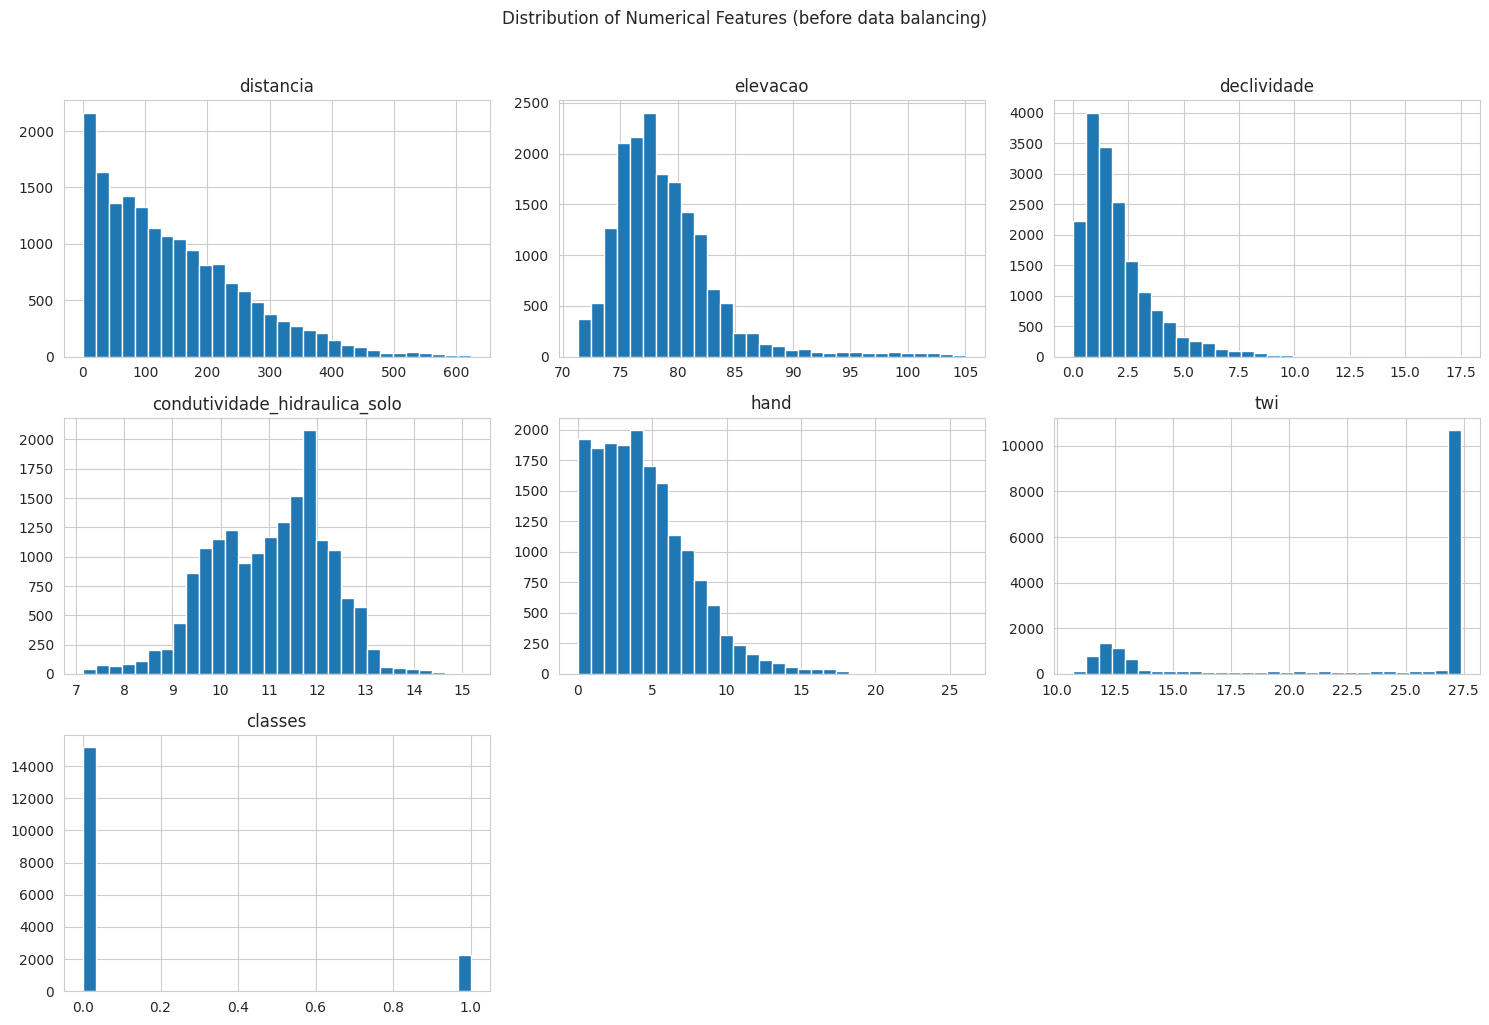

Plot saved as pairplot_features_by_class.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

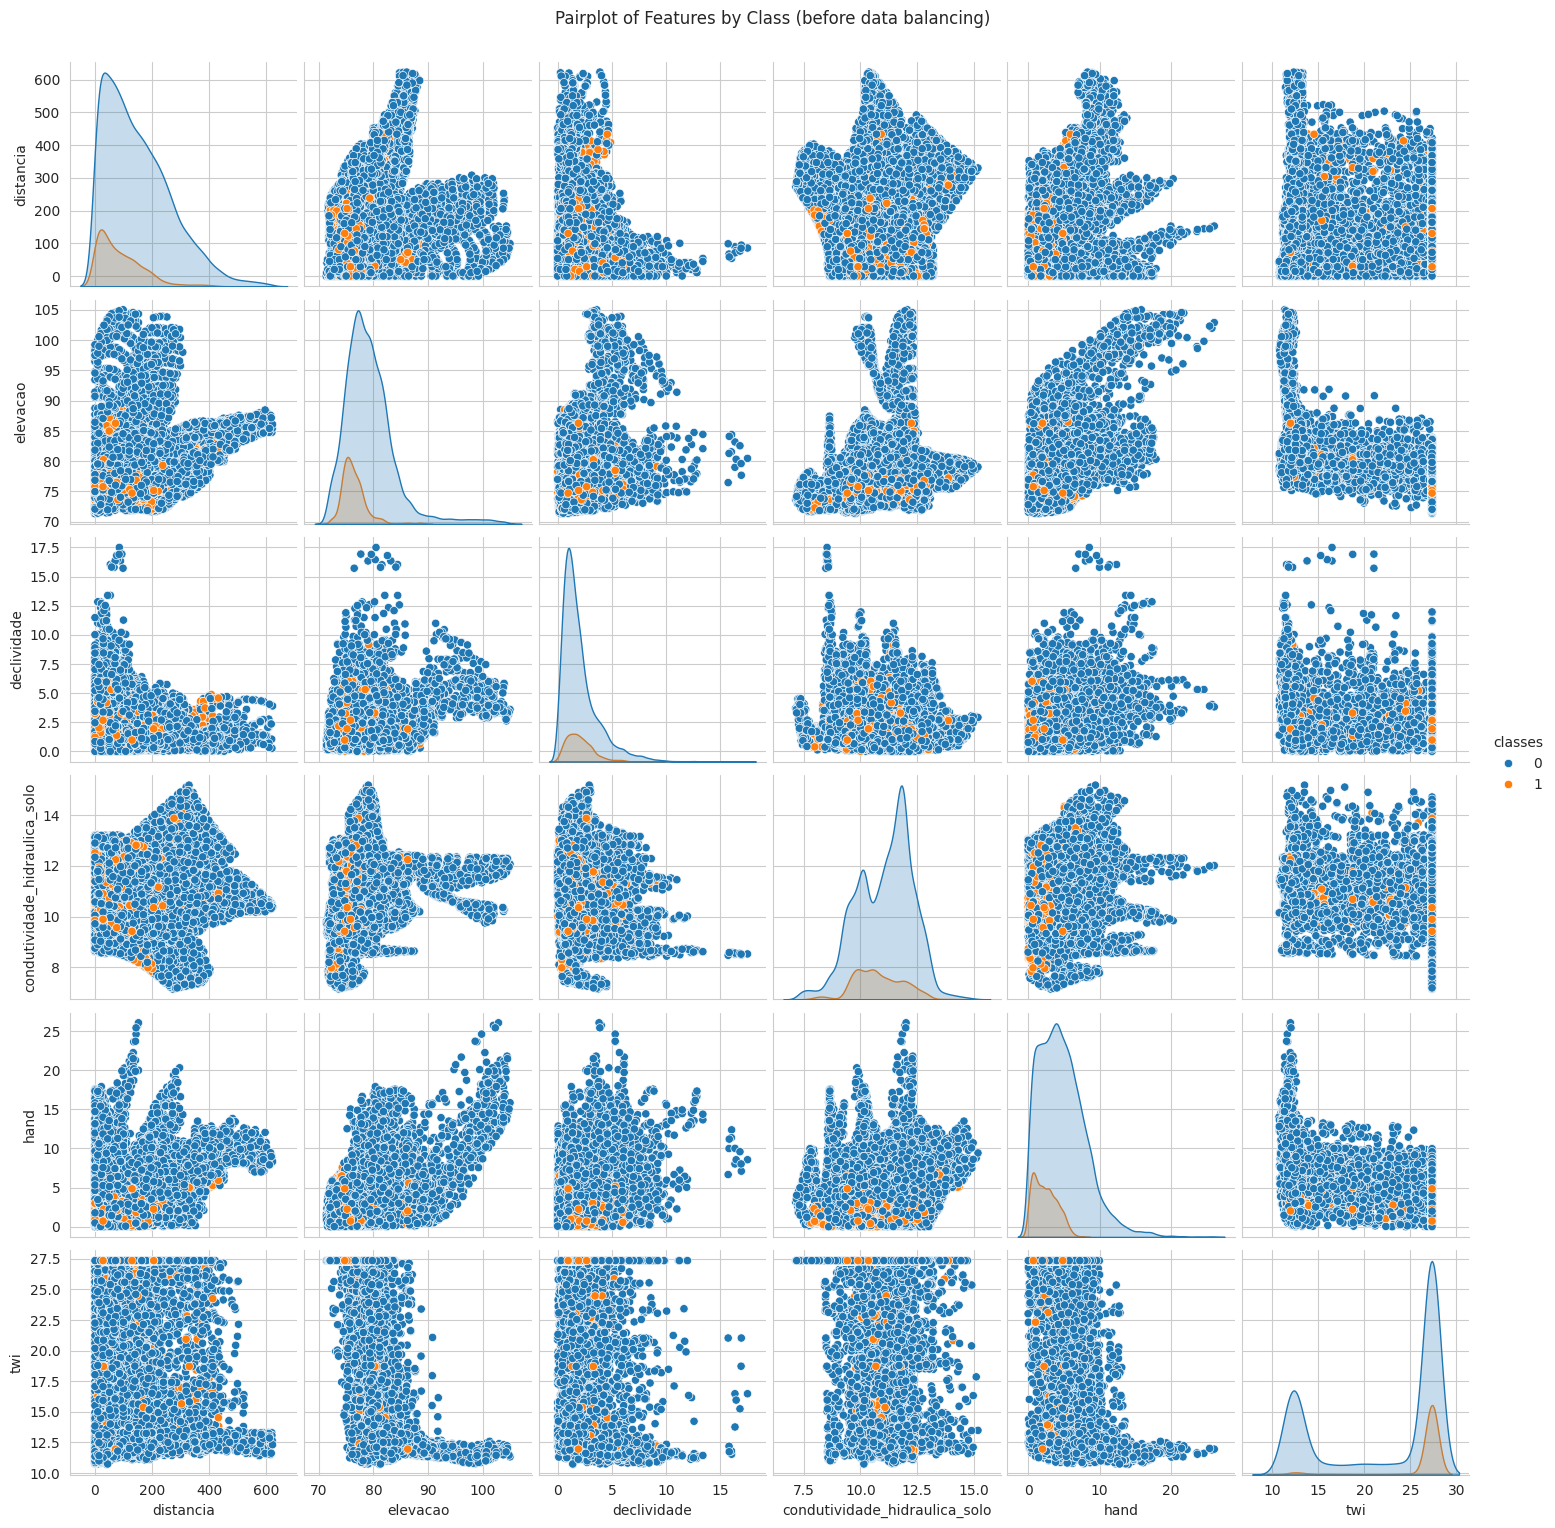

Plot saved as boxplots_features_by_class.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

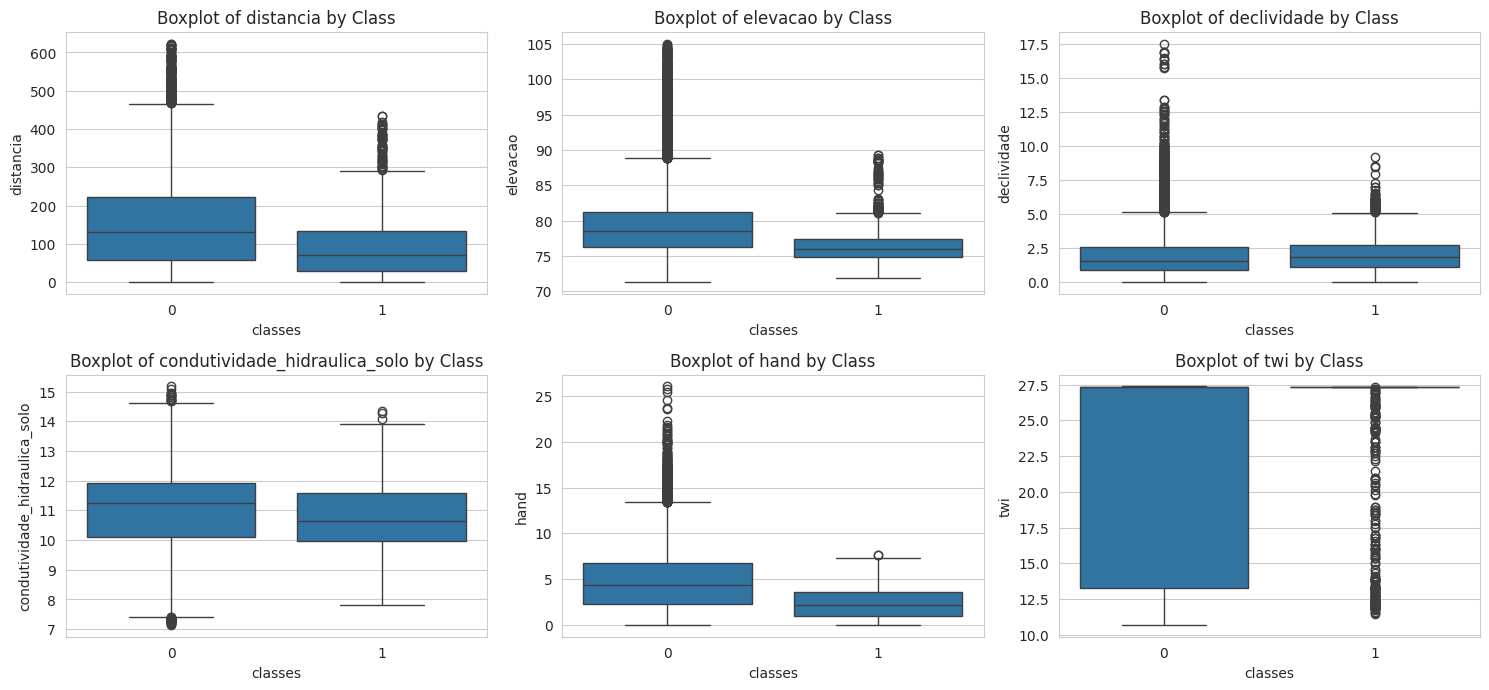

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import files # Import files for downloading

#sample count
print(f"\nTotal number of samples: {len(data)}")

#number of samples per class
print("\nNumber of samples per class:")
print(data['classes'].value_counts())

# Select the relevant columns for the correlation matrix and reorder
data_for_analysis = data.drop(columns=['system:index', 'usocobersolo_classification_2023'])
column_order = ['distancia', 'elevacao', 'declividade', 'condutividade_hidraulica_solo', 'hand', 'twi', 'classes']
data_for_analysis = data_for_analysis[column_order]

# Visualize distributions of numerical features
fig_hist = data_for_analysis.hist(bins=30, figsize=(15, 10))
plt.suptitle('Distribution of Numerical Features (before data balancing)', y=1.02)
plt.tight_layout()
plot_filename_hist = 'distribution_numerical_features.png'
plt.savefig(plot_filename_hist, dpi=300)
print(f"Plot saved as {plot_filename_hist}")
files.download(plot_filename_hist)
plt.show()

# Visualize relationships between features using pairplot
fig_pairplot = sns.pairplot(data_for_analysis, hue='classes', diag_kind='kde')
plt.suptitle('Pairplot of Features by Class (before data balancing)', y=1.02)
plot_filename_pairplot = 'pairplot_features_by_class.png'
plt.savefig(plot_filename_pairplot, dpi=300)
print(f"Plot saved as {plot_filename_pairplot}")
files.download(plot_filename_pairplot)
plt.show()

# Visualize boxplots for each feature by class
plt.figure(figsize=(15, 10))
for i, col in enumerate(data_for_analysis.columns[:-1]): # Exclude the target variable for individual boxplots
    plt.subplot(3, 3, i + 1) # Changed from 2x2 to 3x3 grid
    sns.boxplot(x='classes', y=col, data=data_for_analysis)
    plt.title(f'Boxplot of {col} by Class')
plt.tight_layout()
plot_filename_boxplots = 'boxplots_features_by_class.png'
plt.savefig(plot_filename_boxplots, dpi=300)
print(f"Plot saved as {plot_filename_boxplots}")
files.download(plot_filename_boxplots)
plt.show()

Pearson Correlation Matrix for all classes:


,distancia,elevacao,declividade,condutividade_hidraulica_solo,hand,twi
distancia,1.000000,0.259690,-0.263022,-0.077836,0.395220,-0.199503
elevacao,0.259690,1.000000,0.198616,0.145922,0.630139,-0.710382
declividade,-0.263022,0.198616,1.000000,-0.097596,0.150702,-0.206593
condutividade_hidraulica_solo,-0.077836,0.145922,-0.097596,1.000000,-0.025037,-0.073508
hand,0.395220,0.630139,0.150702,-0.025037,1.000000,-0.626738
twi,-0.199503,-0.710382,-0.206593,-0.073508,-0.626738,1.000000


Plot saved as pearson_correlation_matrix_all_classes.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

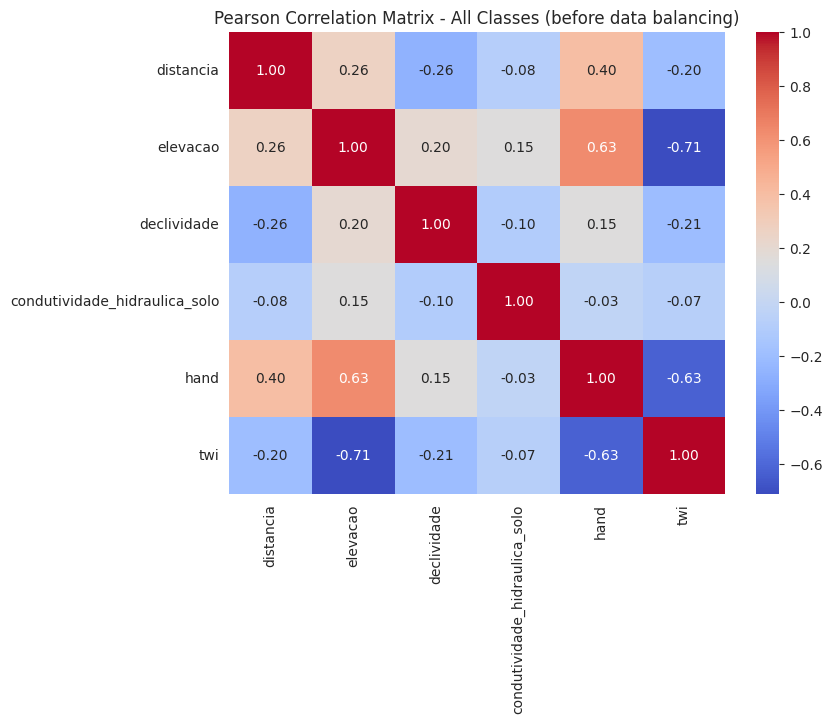

Matriz de Correlação de Pearson para a Classe 0:


,distancia,elevacao,declividade,condutividade_hidraulica_solo,hand,twi
distancia,1.000000,0.231200,-0.278755,-0.099295,0.363711,-0.165137
elevacao,0.231200,1.000000,0.201835,0.123178,0.621723,-0.697029
declividade,-0.278755,0.201835,1.000000,-0.113480,0.156999,-0.208107
condutividade_hidraulica_solo,-0.099295,0.123178,-0.113480,1.000000,-0.050800,-0.057202
hand,0.363711,0.621723,0.156999,-0.050800,1.000000,-0.617711
twi,-0.165137,-0.697029,-0.208107,-0.057202,-0.617711,1.000000


Plot saved as pearson_correlation_matrix_class_0.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

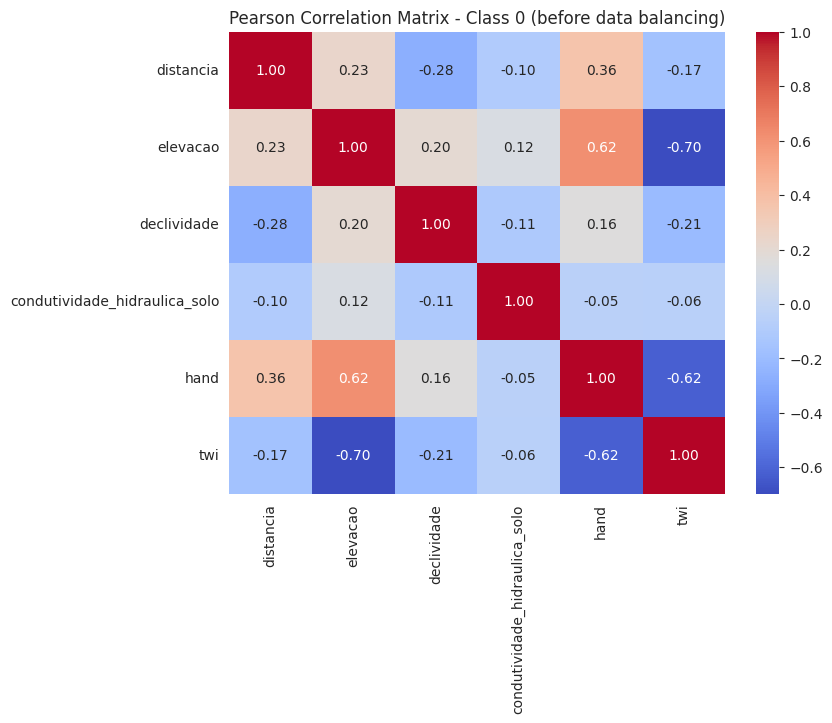


Matriz de Correlação de Pearson para a Classe 1:


,distancia,elevacao,declividade,condutividade_hidraulica_solo,hand,twi
distancia,1.000000,0.211567,-0.118576,-0.020488,0.445344,-0.188440
elevacao,0.211567,1.000000,0.235527,0.332753,0.271557,-0.674879
declividade,-0.118576,0.235527,1.000000,0.071197,0.130380,-0.284749
condutividade_hidraulica_solo,-0.020488,0.332753,0.071197,1.000000,0.046709,-0.101986
hand,0.445344,0.271557,0.130380,0.046709,1.000000,-0.259702
twi,-0.188440,-0.674879,-0.284749,-0.101986,-0.259702,1.000000


Plot saved as pearson_correlation_matrix_class_1.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

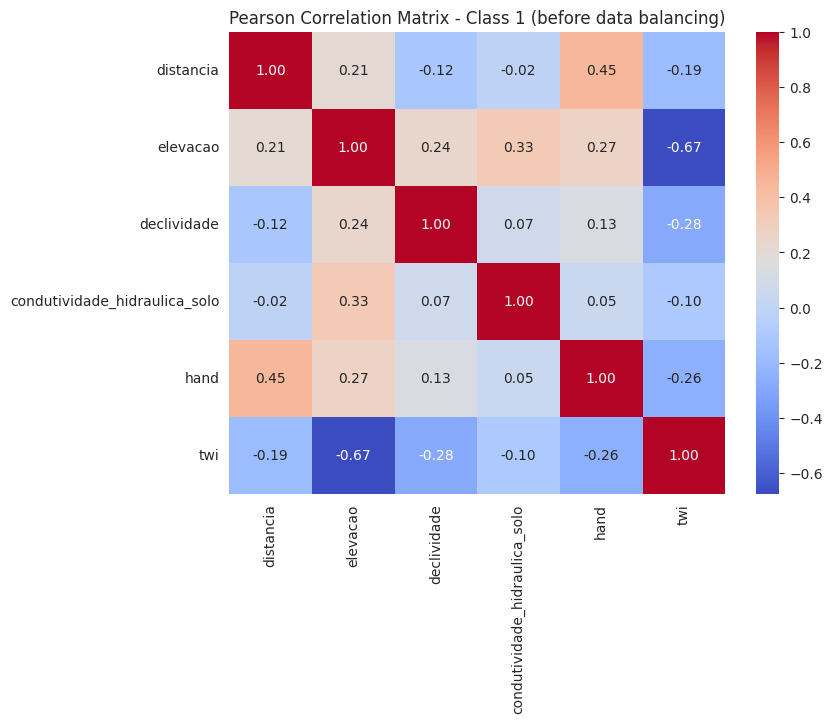

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import files # Import files for downloading

# Calculate the Pearson correlation matrix for all classes
correlation_matrix_all = data_for_analysis.drop(columns=['classes']).corr(method='pearson')

# Display the correlation matrix for all classes
print("Pearson Correlation Matrix for all classes:")
display(correlation_matrix_all)

# Visualize the correlation matrix for all classes as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix_all, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Pearson Correlation Matrix - All Classes (before data balancing)')
plot_filename_all = 'pearson_correlation_matrix_all_classes.png'
plt.savefig(plot_filename_all, dpi=300)
print(f"Plot saved as {plot_filename_all}")
files.download(plot_filename_all)
plt.show()

# Compute the Pearson correlation matrix for class 0
correlation_matrix_class_0 = data_for_analysis[data_for_analysis['classes'] == 0].drop(columns=['classes']).corr(method='pearson')

# Display the correlation matrix for class 0
print("Pearson Correlation Matrix for Class 0:")
display(correlation_matrix_class_0)

# Visualize the correlation matrix for class 0 as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix_class_0, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Pearson Correlation Matrix - Class 0 (before data balancing)')
plot_filename_class0 = 'pearson_correlation_matrix_class_0.png'
plt.savefig(plot_filename_class0, dpi=300)
print(f"Plot saved as {plot_filename_class0}")
files.download(plot_filename_class0)
plt.show()

# Compute the Pearson correlation matrix for class 1
correlation_matrix_class_1 = data_for_analysis[data_for_analysis['classes'] == 1].drop(columns=['classes']).corr(method='pearson')

# Display the correlation matrix for class 1
print("\nPearson Correlation Matrix for Class 1:")
display(correlation_matrix_class_1)

# Visualize the correlation matrix for class 1 as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix_class_1, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Pearson Correlation Matrix - Class 1 (before data balancing)')
plot_filename_class1 = 'pearson_correlation_matrix_class_1.png'
plt.savefig(plot_filename_class1, dpi=300)
print(f"Plot saved as {plot_filename_class1}")
files.download(plot_filename_class1)
plt.show()

In [67]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# All classes
X_vif = data_for_analysis.drop(columns=['classes'])
X_vif = sm.add_constant(X_vif)  # <-- add the constant

vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i)
                   for i in range(X_vif.shape[1])]
vif_data = vif_data[vif_data["feature"] != "const"]  # remove the constant from the table
print("Variance Inflation Factor (VIF) for all features:")
display(vif_data)


'''VIF Value Interpretation
1       No correlation with other variables
1–5     Moderate correlation, generally acceptable
> 5     Concerning multicollinearity
> 10    Very high – should remove or combine variables'''

Variance Inflation Factor (VIF) for all features:


,feature,VIF
1,distancia,1.392449
2,elevacao,2.400577
3,declividade,1.237266
4,condutividade_hidraulica_solo,1.082930
5,hand,2.120038
6,twi,2.288231


'Valor do VIF Interpretação\n1       Nenhuma correlação com outras variáveis\n1–5     Correlação moderada, geralmente aceitável\n> 5     Multicolinearidade preocupante\n> 10    Muito alta – deve remover ou combinar variáveis'

In [68]:
import pandas as pd

# Generate basic statistics for the entire data_for_analysis DataFrame
print("Basic Statistics for the entire dataset:")
display(data_for_analysis.describe())

# Generate basic statistics for Class 0
print("\nBasic Statistics for Class 0:")
display(data_for_analysis[data_for_analysis['classes'] == 0].describe())

# Generate basic statistics for Class 1
print("\nBasic Statistics for Class 1:")
display(data_for_analysis[data_for_analysis['classes'] == 1].describe())

Basic Statistics for the entire dataset:


,distancia,elevacao,declividade,condutividade_hidraulica_solo,hand,twi,classes
count,17456.000000,17456.000000,17456.000000,17456.000000,17456.000000,17456.000000,17456.000000
mean,143.095575,78.907145,2.036244,11.019510,4.489778,22.763923,0.130614
std,114.702247,4.656308,1.693599,1.212002,3.233039,6.480563,0.336987
min,0.000000,71.331111,0.000000,7.146935,0.000000,10.706370,0.000000
25%,50.000000,75.876389,0.910844,10.097617,2.000000,14.743832,0.000000
50%,120.000000,78.006111,1.566496,11.166232,4.000000,27.356215,0.000000
75%,210.950231,80.906667,2.616927,11.911905,6.287385,27.356215,0.000000
max,622.896460,105.026667,17.502447,15.175337,26.066828,27.368484,1.000000



Basic Statistics for Class 0:


,distancia,elevacao,declividade,condutividade_hidraulica_solo,hand,twi,classes
count,15176.000000,15176.000000,15176.000000,15176.000000,15176.000000,15176.000000,15176.0
mean,151.281690,79.289823,2.037681,11.053191,4.805920,22.212249,0.0
std,116.992654,4.797593,1.751426,1.231274,3.296772,6.659888,0.0
min,0.000000,71.331111,0.000000,7.146935,0.000000,10.706370,0.0
25%,58.309519,76.242222,0.888080,10.120286,2.256000,13.257902,0.0
50%,130.000000,78.512778,1.524052,11.242111,4.356390,27.356215,0.0
75%,221.528585,81.269444,2.601469,11.929087,6.706660,27.356215,0.0
max,622.896460,105.026667,17.502447,15.175337,26.066828,27.368484,0.0



Basic Statistics for Class 1:


,distancia,elevacao,declividade,condutividade_hidraulica_solo,hand,twi,classes
count,2280.000000,2280.000000,2280.000000,2280.000000,2280.000000,2280.000000,2280.0
mean,88.607639,76.359983,2.026679,10.795321,2.385491,26.435944,1.0
std,78.818348,2.308858,1.242145,1.047958,1.609509,3.287763,0.0
min,0.000000,71.955556,0.009019,7.820482,0.000000,11.460764,1.0
25%,28.284271,74.880000,1.098138,9.981263,0.985611,27.356215,1.0
50%,70.000000,75.952778,1.829236,10.660456,2.184832,27.356215,1.0
75%,133.603500,77.353333,2.702253,11.603660,3.593650,27.356215,1.0
max,434.165867,89.353333,9.151323,14.340008,7.662619,27.356215,1.0


In [69]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans # Changed from DBSCAN to KMeans
from sklearn.metrics import silhouette_score # For automatic selection of k
import numpy as np
import pandas as pd

# --- NEW STEP: Set aside 15% of the data for future testing ---
# This split is stratified by the 'classes' column to ensure statistical adequacy.
# In addition, the sampling will seek feature diversity.
# The '.geo' column is kept in the test set for future use in plots.

# 1. Identify the numerical features for clustering
numerical_features = [
    'condutividade_hidraulica_solo', 'declividade', 'distancia',
    'elevacao', 'hand', 'twi'
]

# Make sure these columns exist in the 'data' dataframe before proceeding
features_for_clustering = data[numerical_features]

# 2. Scale the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features_for_clustering)

# 3. Apply KMeans++ to create diversity clusters, with k selected automatically
# We will use the Silhouette method to determine the ideal number of clusters (k).
range_n_clusters = range(5, 11) # Test k from 5 to 10, as requested
silhouette_scores = []

print("Computing Silhouette Scores for different values of k...")
for k in range_n_clusters:
    kmeans_model = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init='auto')
    cluster_labels = kmeans_model.fit_predict(scaled_features)
    # The Silhouette Score is defined only if there is more than one cluster
    if len(np.unique(cluster_labels)) > 1:
        score = silhouette_score(scaled_features, cluster_labels)
        silhouette_scores.append(score)
        print(f"k={k}: Silhouette Score = {score:.4f}")
    else:
        silhouette_scores.append(-1) # Penalizes k=1 or cases with only one cluster

# Select the k with the highest Silhouette Score
if len(silhouette_scores) > 0 and max(silhouette_scores) > -1:
    optimal_k_index = np.argmax(silhouette_scores)
    optimal_k = range_n_clusters[optimal_k_index]
    print(f"\nNumber of clusters (k) selected automatically: {optimal_k} (with Silhouette Score of {silhouette_scores[optimal_k_index]:.4f})")
else:
    optimal_k = 5 # Fallback if no valid k is found or only one cluster, using the new minimum
    print(f"\nCould not determine an optimal k, using default k of {optimal_k}.")

kmeans_clustering = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init='auto')
data['feature_clusters'] = kmeans_clustering.fit_predict(scaled_features)

# 4. Create a combined stratification key (class + feature cluster)
# This ensures the split is stratified by both class and feature diversity.
# KMeans does not generate -1 labels; all points are assigned to a cluster.
data['combined_stratify_key'] = data['classes'].astype(str) + '_' + data['feature_clusters'].astype(str)

# Check for strata with few samples before splitting
# This is important to avoid errors in train_test_split
stratify_counts = data['combined_stratify_key'].value_counts()
problematic_keys = stratify_counts[stratify_counts < 2].index.tolist()

if problematic_keys:
    print("Attention: Some combined strata have fewer than 2 samples. Adjusting to allow stratification.")

    # Find the non-problematic stratum with the fewest samples
    # Exclude the problematic strata from consideration
    non_problematic_counts = stratify_counts[stratify_counts >= 2]
    if not non_problematic_counts.empty:
        # Sort to find the smallest non-problematic stratum
        smallest_non_problematic_key = non_problematic_counts.idxmin()
        print(f"Problematic strata: {problematic_keys}")
        print(f"Target stratum for merging: {smallest_non_problematic_key}")

        # Reassign the 'combined_stratify_key' values for the problematic samples
        for key in problematic_keys:
            data.loc[data['combined_stratify_key'] == key, 'combined_stratify_key'] = smallest_non_problematic_key
        print(f"Samples from strata {problematic_keys} were moved to stratum {smallest_non_problematic_key}.")
    else:
        # Fallback if no non-problematic strata exist (unlikely in this scenario)
        print("There are no non-problematic strata to merge the samples into. Consider adjusting the KMeans parameters or the sample size.")

# 5. Set aside 15% of the data for future testing, using the combined stratification key
data_train_full, data_test_full = train_test_split(
    data,
    test_size=0.15,
    random_state=42,
    stratify=data['combined_stratify_key'] # Use the combined stratification key
)

# Display shapes and distributions after the split
print(f"Training set shape (85%): {data_train_full.shape}")
print(f"Test set shape (15%): {data_test_full.shape}")
print("\nClass distribution in the training set:")
print(data_train_full['classes'].value_counts())
print("\nClass distribution in the test set:")
print(data_test_full['classes'].value_counts())

# Display the distribution of the combined stratification key to check diversity
print("\nDistribution of the combined classes (classes and feature clusters) in the training set:")
print(data_train_full['combined_stratify_key'].value_counts())

print("\nDistribution of the combined classes (classes and feature clusters) in the test set:")
print(data_test_full['combined_stratify_key'].value_counts())

# Remove the auxiliary columns created for stratification from the resulting dataframes
data_train_full = data_train_full.drop(columns=['feature_clusters', 'combined_stratify_key'])
data_test_full = data_test_full.drop(columns=['feature_clusters', 'combined_stratify_key'])

# Display the first rows of the test set
data_test_full.head()

Calculando Silhouette Scores para diferentes valores de k...
k=5: Silhouette Score = 0.2396
k=6: Silhouette Score = 0.2489
k=7: Silhouette Score = 0.2618
k=8: Silhouette Score = 0.2551
k=9: Silhouette Score = 0.2590
k=10: Silhouette Score = 0.2525

Número de clusters (k) selecionado automaticamente: 7 (com Silhouette Score de 0.2618)
Shape do conjunto de treinamento (85%): (14837, 12)
Shape do conjunto de teste (15%): (2619, 12)

Distribuição das classes no conjunto de treinamento:
classes
0    12899
1     1938
Name: count, dtype: int64

Distribuição das classes no conjunto de teste:
classes
0    2277
1     342
Name: count, dtype: int64

Distribuição das classes combinadas (classes e clusters de features) no conjunto de treinamento:
combined_stratify_key
0_1    3642
0_4    2576
0_0    2496
0_3    1953
0_5    1031
1_3     916
0_2     764
1_1     695
0_6     437
1_0     181
1_4      63
1_2      55
1_5      28
Name: count, dtype: int64

Distribuição das classes combinadas (classes e clust

,system:index,classes,condutividade_hidraulica_solo,declividade,distancia,elevacao,hand,twi,usocobersolo_classification_2023,.geo
5778,11681,0,12.099247,1.628724,144.222051,76.282222,2.145713,27.356215,3,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
1294,15249,1,11.911459,1.621510,20.000000,75.713333,1.196076,27.356215,25,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
1041,16957,1,11.423248,1.034906,10.000000,73.255556,4.118876,27.356215,25,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
11887,3791,0,11.419123,0.710486,340.147027,86.386667,10.009543,26.201317,24,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
8054,1702,0,11.739087,3.656768,143.178211,75.012222,0.650180,27.356215,3,"{""geodesic"":false,""type"":""Point"",""coordinates""..."


--- Análise de Diversificação do data_test_full ---


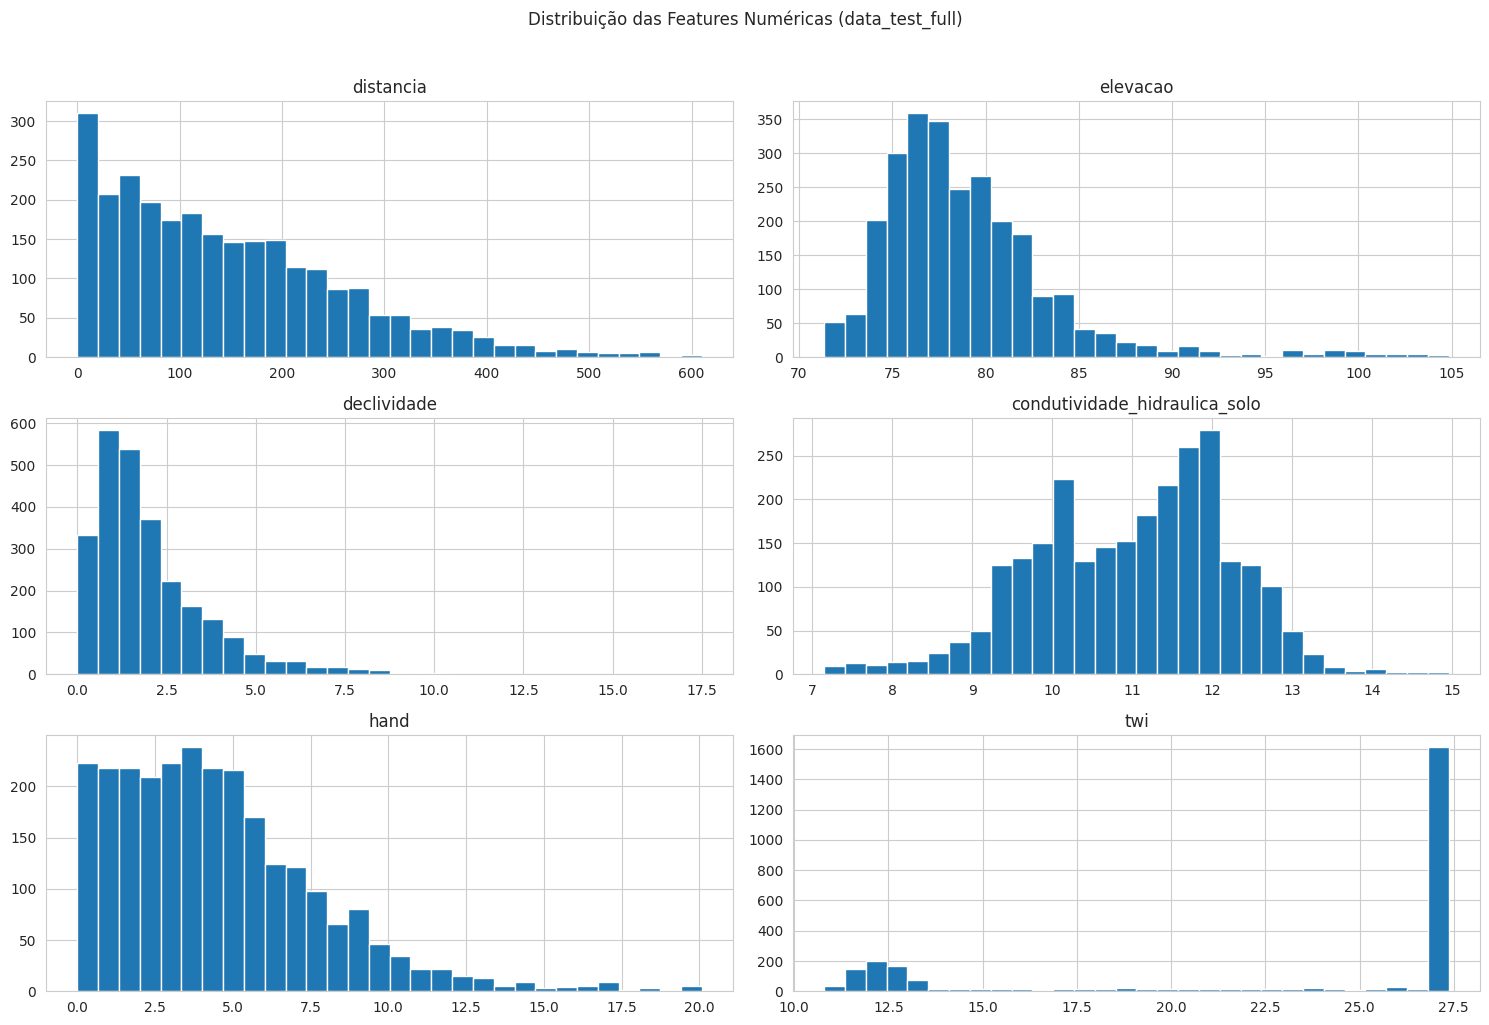

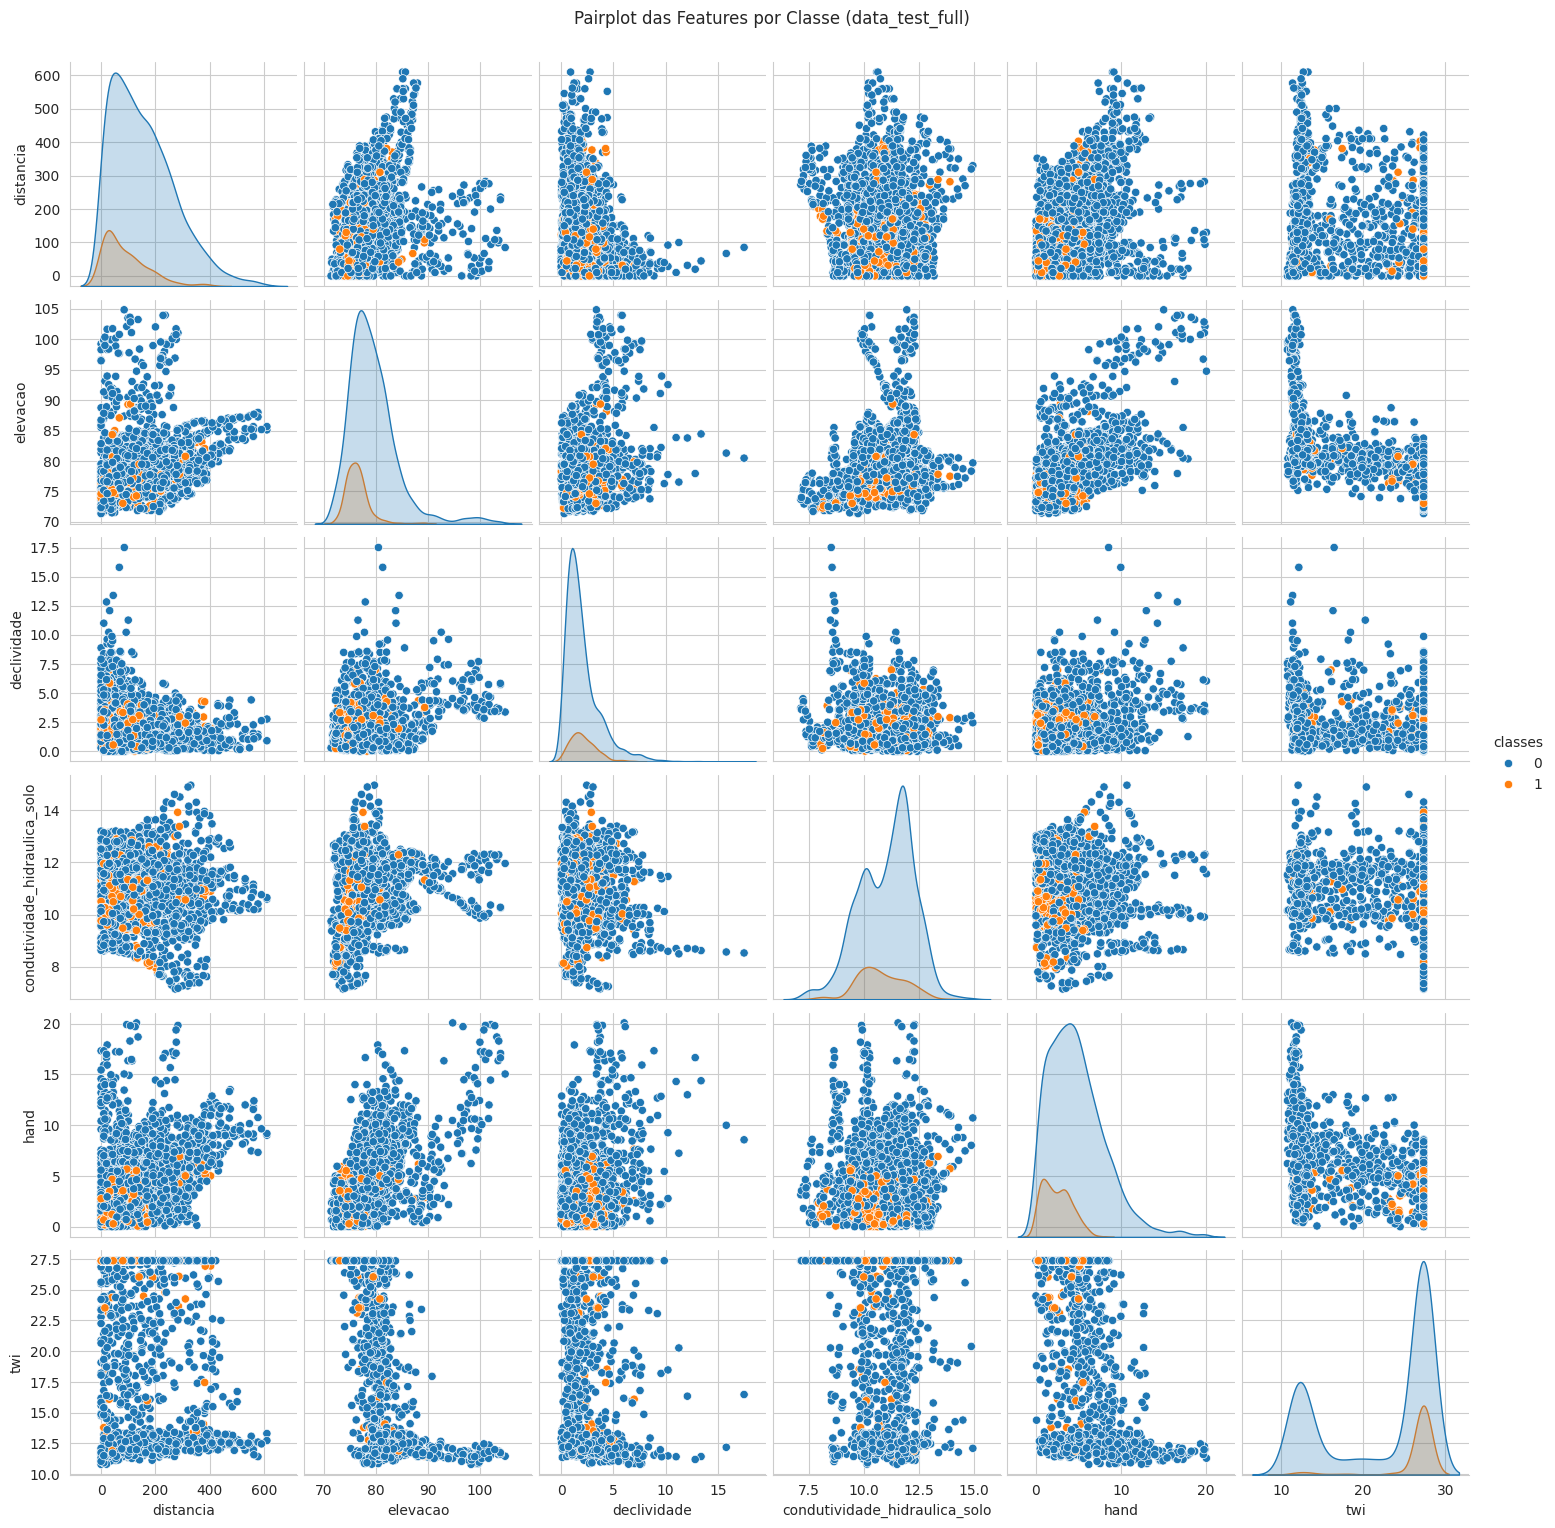

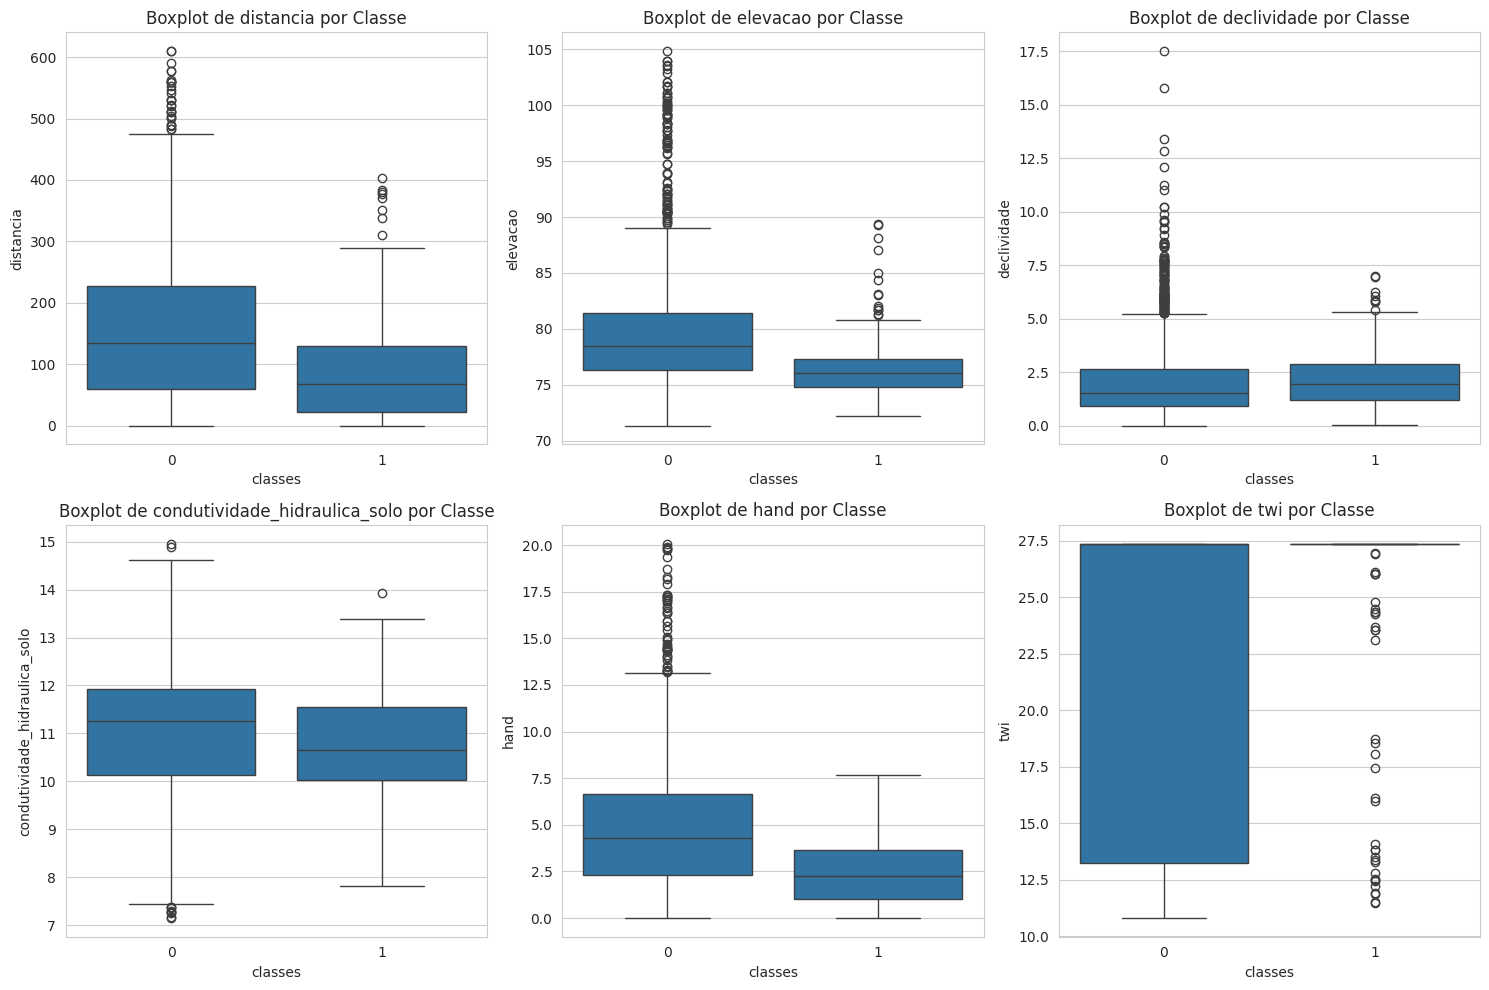


Matriz de Correlação de Pearson (data_test_full):


,distancia,elevacao,declividade,condutividade_hidraulica_solo,hand,twi
distancia,1.000000,0.240177,-0.278970,-0.084323,0.377769,-0.175016
elevacao,0.240177,1.000000,0.204210,0.149755,0.621410,-0.717407
declividade,-0.278970,0.204210,1.000000,-0.108139,0.169131,-0.206784
condutividade_hidraulica_solo,-0.084323,0.149755,-0.108139,1.000000,-0.052846,-0.059078
hand,0.377769,0.621410,0.169131,-0.052846,1.000000,-0.625673
twi,-0.175016,-0.717407,-0.206784,-0.059078,-0.625673,1.000000


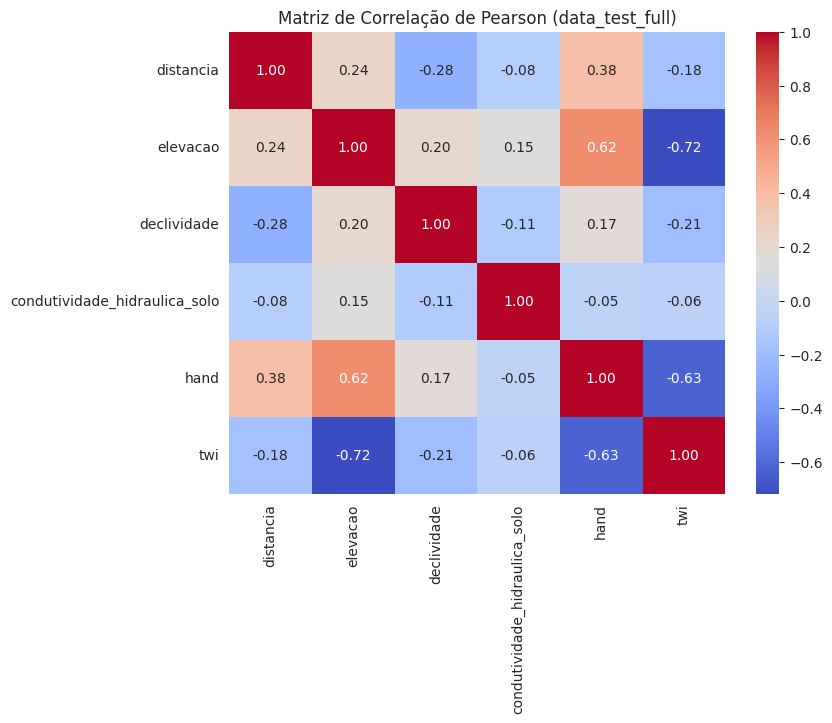


Estatísticas Básicas (data_test_full - Geral):


,distancia,elevacao,declividade,condutividade_hidraulica_solo,hand,twi,classes
count,2619.000000,2619.000000,2619.000000,2619.000000,2619.000000,2619.000000,2619.000000
mean,146.275243,79.005513,2.049110,11.010220,4.487515,22.728591,0.130584
std,114.537977,4.769849,1.701467,1.213956,3.269958,6.508817,0.337009
min,0.000000,71.345556,0.000000,7.146935,0.000000,10.797255,0.000000
25%,53.851648,75.945000,0.925106,10.108079,2.000000,14.635587,0.000000
50%,123.693169,77.943333,1.584612,11.186299,3.982626,27.356215,0.000000
75%,216.333077,80.981667,2.641617,11.904919,6.192701,27.356215,0.000000
max,610.000000,104.851111,17.502447,14.962286,20.085115,27.368484,1.000000



Estatísticas Básicas (data_test_full - Classe 0):


,distancia,elevacao,declividade,condutividade_hidraulica_solo,hand,twi,classes
count,2277.000000,2277.000000,2277.000000,2277.000000,2277.000000,2277.000000,2277.0
mean,154.845833,79.403152,2.041378,11.041139,4.793157,22.171852,0.0
std,116.322613,4.910996,1.759631,1.234082,3.343009,6.690283,0.0
min,0.000000,71.345556,0.000000,7.146935,0.000000,10.797255,0.0
25%,60.000000,76.281111,0.889840,10.125713,2.301505,13.226516,0.0
50%,134.164079,78.491111,1.533670,11.250346,4.295491,27.356215,0.0
75%,228.035085,81.378889,2.620677,11.920350,6.644951,27.356215,0.0
max,610.000000,104.851111,17.502447,14.962286,20.085115,27.368484,0.0



Estatísticas Básicas (data_test_full - Classe 1):


,distancia,elevacao,declividade,condutividade_hidraulica_solo,hand,twi,classes
count,342.000000,342.000000,342.000000,342.000000,342.000000,342.000000,342.0
mean,89.213153,76.358070,2.100587,10.804359,2.452581,26.435301,1.0
std,81.556100,2.369114,1.247707,1.048941,1.650085,3.263835,0.0
min,0.000000,72.227778,0.014255,7.820482,0.000000,11.460764,1.0
25%,22.360680,74.791944,1.211533,10.033906,0.999712,27.356215,1.0
50%,67.082039,76.005000,1.932539,10.647309,2.228686,27.356215,1.0
75%,130.000000,77.251944,2.859945,11.557386,3.665275,27.356215,1.0
max,403.112887,89.353333,6.987566,13.922343,7.662619,27.356215,1.0



--- Análise de Multicolinearidade (VIF) para data_test_full ---
Fator de Inflação da Variância (VIF) para todas as features (data_test_full):


,feature,VIF
1,distancia,1.398923
2,elevacao,2.449043
3,declividade,1.264345
4,condutividade_hidraulica_solo,1.100978
5,hand,2.110431
6,twi,2.341031



Interpretação do Valor do VIF:
1       Nenhuma correlação com outras variáveis
1–5     Correlação moderada, geralmente aceitável
> 5     Multicolinearidade preocupante
> 10    Muito alta – deve remover ou combinar variáveis


In [70]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Ensure data_test_full is available in the environment.
# If it is not, this cell may fail.
# data_test_full is generated in cell 7Fb7vf9K7T7C.

# Select the relevant columns for analysis of data_test_full
# Exclude 'system:index', 'usocobersolo_classification_2023', and '.geo'
# And ensure that 'classes' is the target variable.
data_test_analysis = data_test_full.drop(columns=['system:index', 'usocobersolo_classification_2023', '.geo'])
column_order = ['distancia', 'elevacao', 'declividade', 'condutividade_hidraulica_solo', 'hand', 'twi', 'classes']
data_test_analysis = data_test_analysis[column_order]

print("--- Diversification Analysis of data_test_full ---")

# 1. Visualize the distribution of numerical features (Histograms)
data_test_analysis.drop(columns=['classes']).hist(bins=30, figsize=(15, 10))
plt.suptitle('Distribution of Numerical Features (data_test_full)', y=1.02)
plt.tight_layout()
plt.show()

# 2. Visualize the relationships between features using pairplot
sns.pairplot(data_test_analysis, hue='classes', diag_kind='kde')
plt.suptitle('Pairplot of Features by Class (data_test_full)', y=1.02)
plt.show()

# 3. Visualize boxplots for each feature by class
plt.figure(figsize=(15, 10))
features_to_boxplot = data_test_analysis.columns.drop('classes')
num_features = len(features_to_boxplot)
rows = (num_features + 2) // 3 # Compute the rows needed for a 3-column grid
for i, col in enumerate(features_to_boxplot):
    plt.subplot(rows, 3, i + 1)
    sns.boxplot(x='classes', y=col, data=data_test_analysis)
    plt.title(f'Boxplot of {col} by Class')
plt.tight_layout()
plt.show()

# 4. Correlation Matrix Heatmap
correlation_matrix_test = data_test_analysis.drop(columns=['classes']).corr(method='pearson')
print("\nPearson Correlation Matrix (data_test_full):")
display(correlation_matrix_test)
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix_test, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Pearson Correlation Matrix (data_test_full)')
plt.show()

# 5. Basic Statistics
print("\nBasic Statistics (data_test_full - Overall):")
display(data_test_analysis.describe())

print("\nBasic Statistics (data_test_full - Class 0):")
display(data_test_analysis[data_test_analysis['classes'] == 0].describe())

print("\nBasic Statistics (data_test_full - Class 1):")
display(data_test_analysis[data_test_analysis['classes'] == 1].describe())

# 6. Variance Inflation Factor (VIF)
print("\n--- Multicollinearity Analysis (VIF) for data_test_full ---")

# All classes
X_vif_test = data_test_analysis.drop(columns=['classes'])
X_vif_test = sm.add_constant(X_vif_test)

vif_data_test = pd.DataFrame()
vif_data_test["feature"] = X_vif_test.columns
vif_data_test["VIF"] = [variance_inflation_factor(X_vif_test.values, i)
                       for i in range(X_vif_test.shape[1])]
vif_data_test = vif_data_test[vif_data_test["feature"] != "const"]
print("Variance Inflation Factor (VIF) for all features (data_test_full):")
display(vif_data_test)

print("\nVIF Value Interpretation:")
print("1       No correlation with other variables")
print("1–5     Moderate correlation, generally acceptable")
print("> 5     Concerning multicollinearity")
print("> 10    Very high – should remove or combine variables")

In [71]:
# Prepare X and y for the TRAINING set (for the PU learning pipeline)

# Preserve 'system:index' and '.geo' columns from data_train_full for later re-attachment
# The index of geo_train_for_final_merge will correspond to the original data_train_full index,
# which is essential for re-merging with the final processed DataFrame.
geo_train_for_final_merge = data_train_full[['system:index', '.geo']].copy()

X_train_model = data_train_full.drop(columns=['system:index', 'usocobersolo_classification_2023', 'classes', '.geo'])
y_train_model = data_train_full['classes']

print("\nDistribution of the original classes (now y_train_model):")
print(y_train_model.value_counts())


Distribuição das classes originais (agora y_train_model):
classes
0    12899
1     1938
Name: count, dtype: int64


In [72]:
# Split the TRAINING data into labeled (class 1) and unlabeled (class 0)
X_labeled = X_train_model[y_train_model == 1]
y_labeled = y_train_model[y_train_model == 1]

X_unlabeled = X_train_model[y_train_model == 0]
y_unlabeled = y_train_model[y_train_model == 0]

# Select 20% of the labeled samples as "spies" - (20% of 85% equals 17% of the dataset)
X_spy, X_labeled_train, y_spy, y_labeled_train = train_test_split(
    X_labeled, y_labeled, test_size=0.8, random_state=42, stratify=y_labeled
)

print("\nShape of y_spy:", y_spy.shape)
print("Shape of y_labeled_train:", y_labeled_train.shape)
print("Shape of y_unlabeled:", y_unlabeled.shape)

y_spy_fake = pd.Series([0] * len(y_spy), index=y_spy.index)

# Mix the "spies" with the unlabeled data
X_train_spy = pd.concat([X_labeled_train, X_unlabeled, X_spy])
y_train_spy = pd.concat([y_labeled_train, y_unlabeled, y_spy_fake])

# Shuffle the data
shuffle_index = np.random.permutation(len(X_train_spy))
X_train_spy = X_train_spy.iloc[shuffle_index].reset_index(drop=True)
y_train_spy = y_train_spy.iloc[shuffle_index].reset_index(drop=True)

print('--------------')
print("Shape of X_train_spy:", X_train_spy.shape)
print("Shape of y_train_spy:", y_train_spy.shape)
print("\nValue counts of y_train_spy:")
print(y_train_spy.value_counts())


Shape of y_spy: (387,)
Shape of y_labeled_train: (1551,)
Shape of y_unlabeled: (12899,)
--------------
Shape of X_train_spy: (14837, 6)
Shape of y_train_spy: (14837,)

Value counts of y_train_spy:
0    13286
1     1551
Name: count, dtype: int64


In [73]:
from sklearn.naive_bayes import GaussianNB

# Initialize the Naive Bayes classifier
nb_classifier = GaussianNB()

# Train the classifier with the training data, including the spies
nb_classifier.fit(X_train_spy, y_train_spy)

# Compute the probabilities for the training data
proba_spy = nb_classifier.predict_proba(X_spy)

# Display the first probabilities
print("Probabilities computed by Naive Bayes:")
print(proba_spy[:5])

Probabilidades calculadas pelo Naive Bayes:
[[0.8773582  0.1226418 ]
 [0.41721044 0.58278956]
 [0.46764445 0.53235555]
 [0.40927278 0.59072722]
 [0.56634226 0.43365774]]


In [74]:
proba_positive = proba_spy[:, 1]
print("Positive class probabilities:")
print(proba_positive[:5])

Probabilidades da classe positiva:
[0.1226418  0.58278956 0.53235555 0.59072722 0.43365774]


In [75]:
import numpy as np

mean = np.mean(proba_positive)
std_dev = np.std(proba_positive)
median = np.median(proba_positive)
quartiles = np.percentile(proba_positive, [25, 50, 75])

print(f"Mean: {mean:.2f}")
print(f"Standard deviation: {std_dev:.2f}")
print(f"Median: {median:.2f}")
print(f"First quartile (Q1): {quartiles[0]:.2f}")

cutoff_threshold = mean - std_dev
print(f"Cutoff threshold defined as Mean - Standard Deviation: {cutoff_threshold:.2f}")

Média: 0.61
Desvio padrão: 0.25
Mediana: 0.69
Primeiro quartil (Q1): 0.47
Limiar de corte definido como Média - Desvio Padrão: 0.36


In [76]:
#  verify that most of the spies stay ABOVE the threshold
# (spies are real positives inserted as negatives - they should have high proba)
spies_below = (proba_positive < cutoff_threshold).sum()
print(f"Spies below the threshold: {spies_below}")
spies_total  = len(proba_positive)
print(f"Spies below the threshold: {spies_below}/{spies_total} ({spies_below/spies_total:.1%})")
# If >10% of the spies fall below mu-sigma, this cutoff is unstable for a wide/skewed spy distribution; fall back to Q1 (first quartile): a robust, higher threshold that yields a more conservative, purer positive relabeling
if spies_below / spies_total > 0.10:
    cutoff_threshold = quartiles[0]  # use Q1 as fallback
    print(f"Threshold adjusted to Q1: {cutoff_threshold :.2f}")


Spies abaixo do limiar: 65
Spies abaixo do limiar: 65/387 (16.8%)
Limiar ajustado para Q1: 0.47


Plot saved as histograma_proba_positiva.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

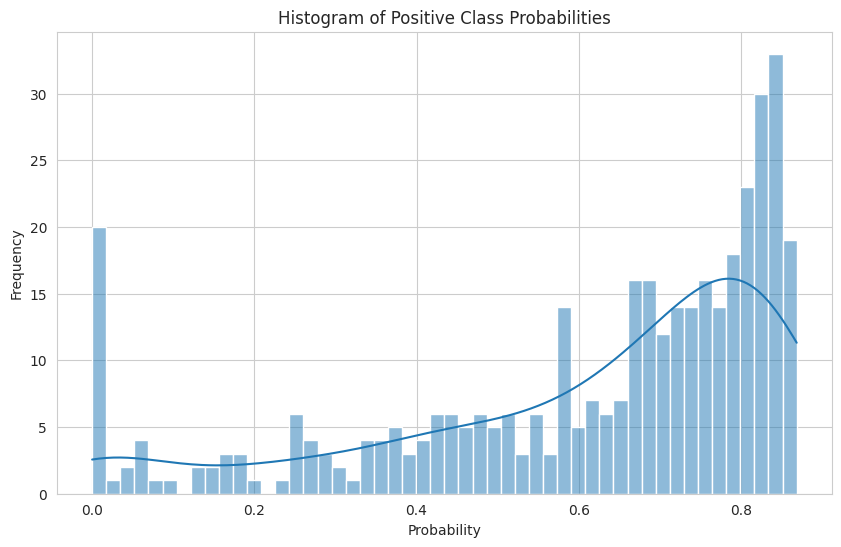

Plot saved as boxplot_proba_positiva.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

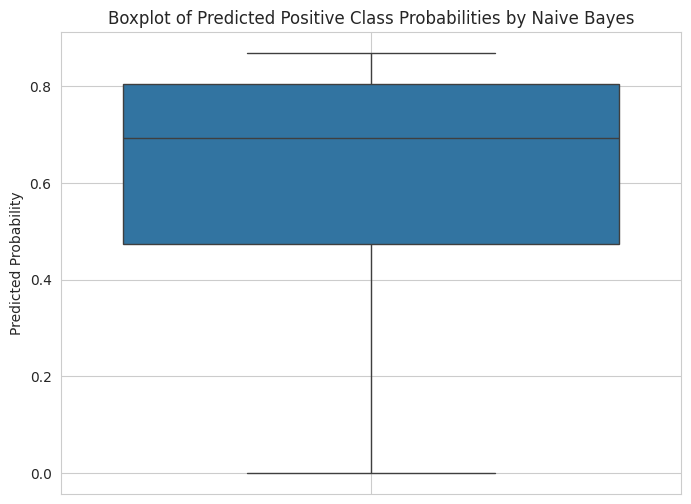

Plot saved as media_desvio_proba_positiva.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

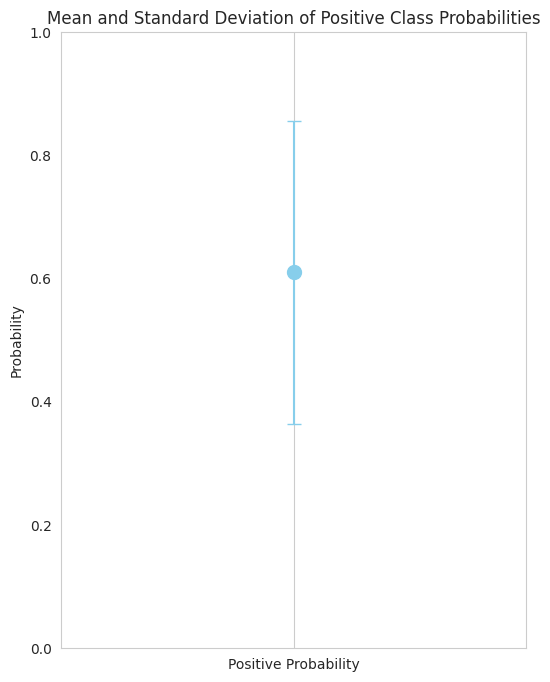

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from google.colab import files # Import files for downloading

# Create the histogram
plt.figure(figsize=(10, 6))
sns.histplot(proba_positive, bins=50, kde=True)
plt.title('Histogram of Positive Class Probabilities')
plt.xlabel('Probability')
plt.ylabel('Frequency')
plt.grid(True)
plot_filename_hist = 'histograma_proba_positiva.png'
plt.savefig(plot_filename_hist, dpi=300)
print(f"Plot saved as {plot_filename_hist}")
files.download(plot_filename_hist)
plt.show()

# Create the boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(y=proba_positive)
plt.title('Boxplot of Predicted Positive Class Probabilities by Naive Bayes')
plt.ylabel('Predicted Probability')
plt.grid(True)
plot_filename_boxplot = 'boxplot_proba_positiva.png'
plt.savefig(plot_filename_boxplot, dpi=300)
print(f"Plot saved as {plot_filename_boxplot}")
files.download(plot_filename_boxplot)
plt.show()

# Create the plot with a point (circle) and error bars
plt.figure(figsize=(6, 8))
plt.errorbar(['Positive Probability'], [mean], yerr=[std_dev], fmt='o', capsize=5, color='skyblue', markersize=10)
plt.title('Mean and Standard Deviation of Positive Class Probabilities')
plt.ylabel('Probability')
plt.ylim(0, 1)  # Set the y-axis limit between 0 and 1
plt.grid(axis='y')
plot_filename_errorbar = 'media_desvio_proba_positiva.png'
plt.savefig(plot_filename_errorbar, dpi=300)
print(f"Plot saved as {plot_filename_errorbar}")
files.download(plot_filename_errorbar)
plt.show()

In [78]:
# Count samples smaller than cutoff_threshold
count_smaller = (proba_positive < cutoff_threshold).sum()

# Count samples greater than cutoff_threshold
count_larger = (proba_positive >= cutoff_threshold).sum()

print(f"Number of samples with probability lower than {cutoff_threshold:.2f}: {count_smaller}")
print(f"Number of samples with probability greater than or equal to {cutoff_threshold:.2f}: {count_larger}")

Número de amostras com probabilidade menor que 0.47: 97
Número de amostras com probabilidade maior ou igual a 0.47: 290


In [79]:
# Predict classes and probabilities for the unlabeled data
predicted_proba = nb_classifier.predict_proba(X_unlabeled)
predicted_classes = nb_classifier.predict(X_unlabeled)


# Create a DataFrame with the unlabeled data and the predicted classes
unlabeled_predictions_df = X_unlabeled.copy()
unlabeled_predictions_df['predicted_classes'] = predicted_classes
unlabeled_predictions_df['proba_class_0'] = predicted_proba[:, 0]
unlabeled_predictions_df['proba_class_1'] = predicted_proba[:, 1]


# Display the first rows of the new DataFrame and the count of predicted classes
print("DataFrame with unlabeled data, predicted classes and probabilities:")
display(unlabeled_predictions_df.head(10))

print("\nCount of predicted classes in the unlabeled data:")
print(unlabeled_predictions_df['predicted_classes'].value_counts())

DataFrame com dados não rotulados, classes previstas e probabilidades:


,condutividade_hidraulica_solo,declividade,distancia,elevacao,hand,twi,predicted_classes,proba_class_0,proba_class_1
7967,10.996667,1.914715,226.274170,81.622222,3.952615,22.391172,0,0.983171,1.682858e-02
2131,10.625418,0.568208,150.000000,84.366667,7.748533,12.428245,0,1.000000,3.141454e-08
12862,8.980372,3.106603,42.426407,77.483333,13.449730,13.867831,0,1.000000,1.037752e-11
2232,10.906574,0.646473,280.000000,77.421111,3.343445,27.356215,0,0.849244,1.507562e-01
10959,10.881488,3.727837,110.453610,81.635556,6.874408,11.911386,0,0.999998,1.701646e-06
5476,9.357740,1.611546,327.566787,78.500000,3.377476,27.356215,0,0.953764,4.623623e-02
12485,9.518896,1.252130,50.000000,72.362222,2.132297,27.356215,1,0.248764,7.512356e-01
12849,12.694439,0.651185,58.309519,72.011111,0.357858,27.356215,0,0.567789,4.322110e-01
15118,11.263632,1.064866,215.870331,79.615556,3.534389,25.000046,0,0.849318,1.506823e-01
8701,9.621425,1.148899,40.000000,73.137778,3.578314,27.356215,1,0.291903,7.080969e-01



Contagem das classes previstas nos dados não rotulados:
predicted_classes
0    9215
1    3684
Name: count, dtype: int64


In [80]:
# Add the new 'new_class' column based on the cutoff threshold
unlabeled_predictions_df['new_class'] = (unlabeled_predictions_df['proba_class_1'] >= cutoff_threshold).astype(int)

# Display the first rows of the DataFrame with the new column
print("DataFrame with the new 'new_class' column:")
display(unlabeled_predictions_df.head(1000))

# Display the value count in the new column
print("\nValue count in the new 'new_class' column:")
print(unlabeled_predictions_df['new_class'].value_counts())

DataFrame com a nova coluna 'new_class':


,condutividade_hidraulica_solo,declividade,distancia,elevacao,hand,twi,predicted_classes,proba_class_0,proba_class_1,new_class
7967,10.996667,1.914715,226.274170,81.622222,3.952615,22.391172,0,0.983171,1.682858e-02,0
2131,10.625418,0.568208,150.000000,84.366667,7.748533,12.428245,0,1.000000,3.141454e-08,0
12862,8.980372,3.106603,42.426407,77.483333,13.449730,13.867831,0,1.000000,1.037752e-11,0
2232,10.906574,0.646473,280.000000,77.421111,3.343445,27.356215,0,0.849244,1.507562e-01,0
10959,10.881488,3.727837,110.453610,81.635556,6.874408,11.911386,0,0.999998,1.701646e-06,0
...,...,...,...,...,...,...,...,...,...,...
9274,11.048097,0.177571,210.000000,77.524444,5.017245,27.356215,0,0.874057,1.259425e-01,0
14920,12.420661,0.192155,172.046505,74.200000,1.882516,27.356215,0,0.533855,4.661451e-01,0
12151,11.173759,0.861185,340.000000,85.746667,9.419959,12.050476,0,1.000000,3.188397e-12,0
11022,8.907001,8.375970,70.710678,77.615556,7.185452,27.356215,0,0.999875,1.251426e-04,0



Contagem de valores na nova coluna 'new_class':
new_class
0    9055
1    3844
Name: count, dtype: int64


In [81]:
unlabeled_predictions_df = unlabeled_predictions_df.drop(columns=['predicted_classes', 'proba_class_0', 'proba_class_1'])
display(unlabeled_predictions_df.head())
print("\nColumns after dropping:")
print(unlabeled_predictions_df.columns)

,condutividade_hidraulica_solo,declividade,distancia,elevacao,hand,twi,new_class
7967,10.996667,1.914715,226.274170,81.622222,3.952615,22.391172,0
2131,10.625418,0.568208,150.000000,84.366667,7.748533,12.428245,0
12862,8.980372,3.106603,42.426407,77.483333,13.449730,13.867831,0
2232,10.906574,0.646473,280.000000,77.421111,3.343445,27.356215,0
10959,10.881488,3.727837,110.453610,81.635556,6.874408,11.911386,0



Columns after dropping:
Index(['condutividade_hidraulica_solo', 'declividade', 'distancia', 'elevacao',
       'hand', 'twi', 'new_class'],
      dtype='object')


In [82]:
print("=== Comparison: Original positives vs NB-labeled ===")
numeric_features = ['condutividade_hidraulica_solo','declividade','distancia','elevacao','hand','twi']

originals = X_labeled[numeric_features].describe()
labeled_nb = unlabeled_predictions_df[unlabeled_predictions_df['new_class']==1][numeric_features].describe()

print("\nOriginal positives (field):")
print(originals.loc[['mean','std','min','max']])
print("\nPositives labeled by NB:")
print(labeled_nb.loc[['mean','std','min','max']])

=== Comparação: Positivos originais vs Rotulados pelo NB ===

Positivos originais (campo):
      condutividade_hidraulica_solo  declividade   distancia   elevacao  \
mean                      10.793727     2.013636   88.500784  76.360321   
std                        1.048047     1.241027   78.346458   2.298685   
min                        7.827418     0.009019    0.000000  71.955556   
max                       14.340008     9.151323  434.165867  88.912222   

          hand        twi  
mean  2.373651  26.436058  
std   1.602384   3.292805  
min   0.000000  11.577346  
max   7.582260  27.356215  

Positivos rotulados pelo NB:
      condutividade_hidraulica_solo  declividade   distancia   elevacao  \
mean                      11.150840     1.655940   73.151805  75.802918   
std                        1.196499     1.079918   56.860208   1.888094   
min                        8.080693     0.000000    0.000000  71.331111   
max                       13.202355     5.521315  240.831892  8

In [83]:
# Create a copy of the X_labeled DataFrame and reset its index
labeled_df = X_labeled.copy()

# Add the 'new_class' column from y_labeled
labeled_df['new_class'] = y_labeled

print(labeled_df['new_class'].value_counts())
print(unlabeled_predictions_df['new_class'].value_counts())

new_class
1    1938
Name: count, dtype: int64
new_class
0    9055
1    3844
Name: count, dtype: int64


In [84]:
# Concatenate labeled and unlabeled dataframes
#combined_df = pd.concat([labeled_df, unlabeled_predictions_df]).merge(geo_train_for_final_merge, left_index=True, right_index=True, how='left')

combined_df = pd.concat([labeled_df, unlabeled_predictions_df], ignore_index=False)
combined_df = combined_df.join(geo_train_for_final_merge, how='left', rsuffix='_geo')
# Check for NaN in .geo after the merge
print(f"Samples without .geo: {combined_df['.geo'].isna().sum()}")

print("\nValue counts of new_class in combined DataFrame:")
print(combined_df['new_class'].value_counts())

print("Combined DataFrame:")
display(combined_df.head())

Amostras sem .geo: 0

Value counts of new_class in combined DataFrame:
new_class
0    9055
1    5782
Name: count, dtype: int64
Combined DataFrame:


,condutividade_hidraulica_solo,declividade,distancia,elevacao,hand,twi,new_class,system:index,.geo
9644,11.856234,0.514435,50.000000,76.987778,2.261648,27.356215,1,15869,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
1370,9.633024,3.055207,14.142136,76.450000,1.955792,27.356215,1,16268,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
9524,12.505327,2.490035,30.000000,76.426667,4.542085,27.356215,1,16176,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
8105,9.660293,0.865827,0.000000,74.067778,2.789109,27.356215,1,15733,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
14839,8.177069,0.453285,161.245155,72.258889,0.976697,27.356215,1,17142,"{""geodesic"":false,""type"":""Point"",""coordinates""..."


Plot saved as numerical_features_hist.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<Figure size 1500x1000 with 0 Axes>

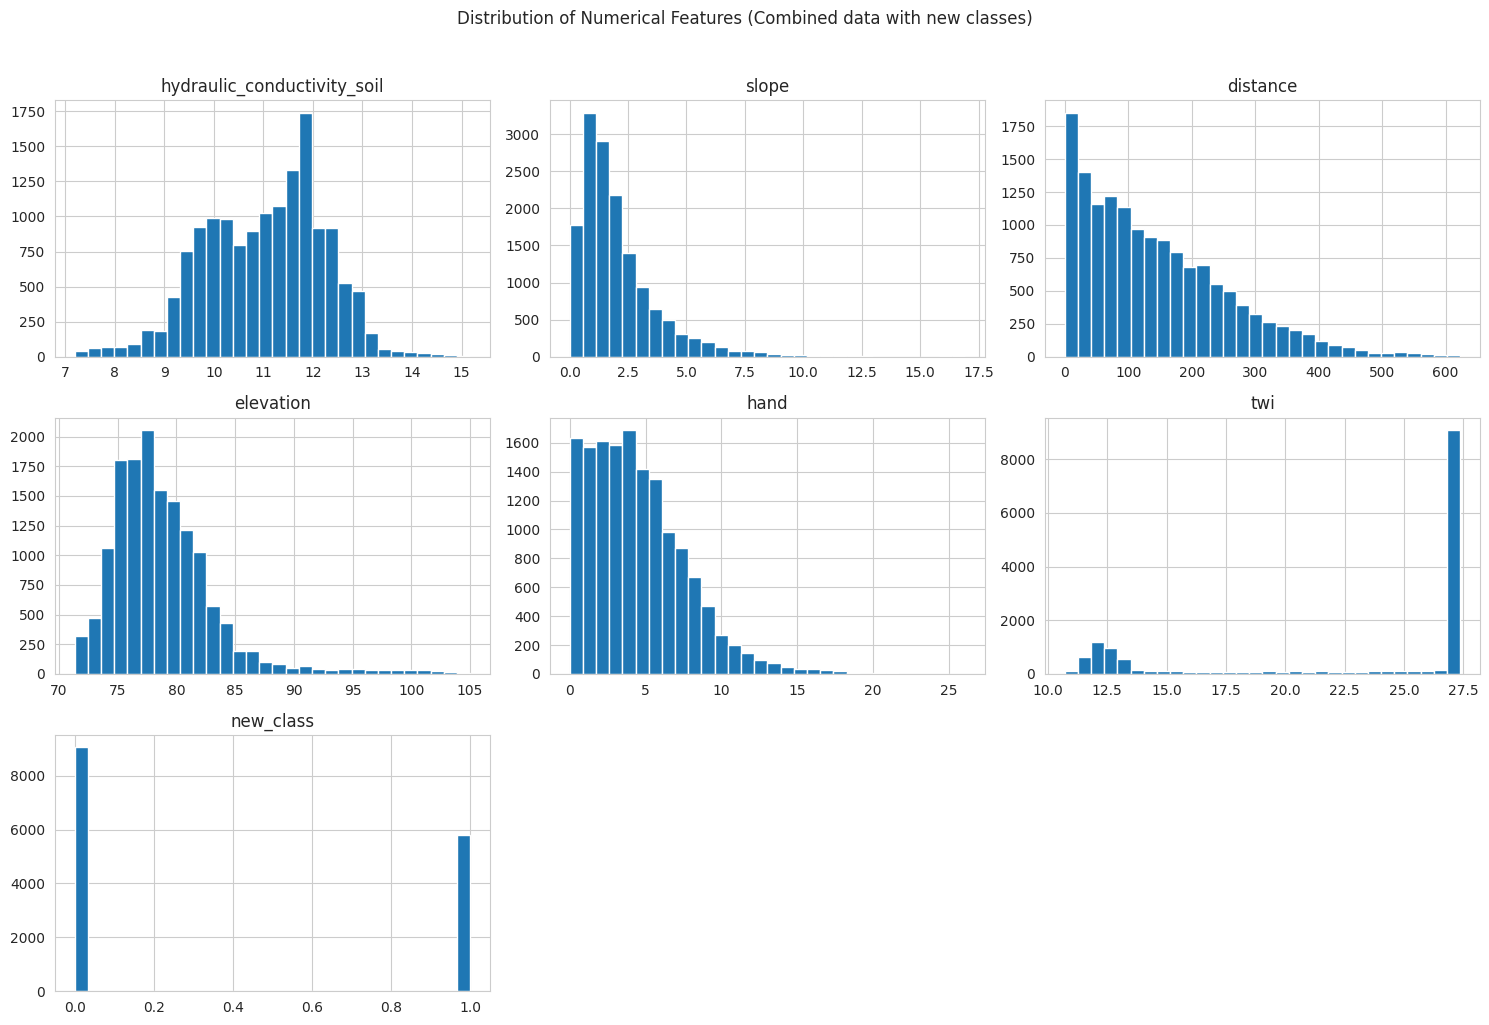

Plot saved as pairplot_new_classes.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

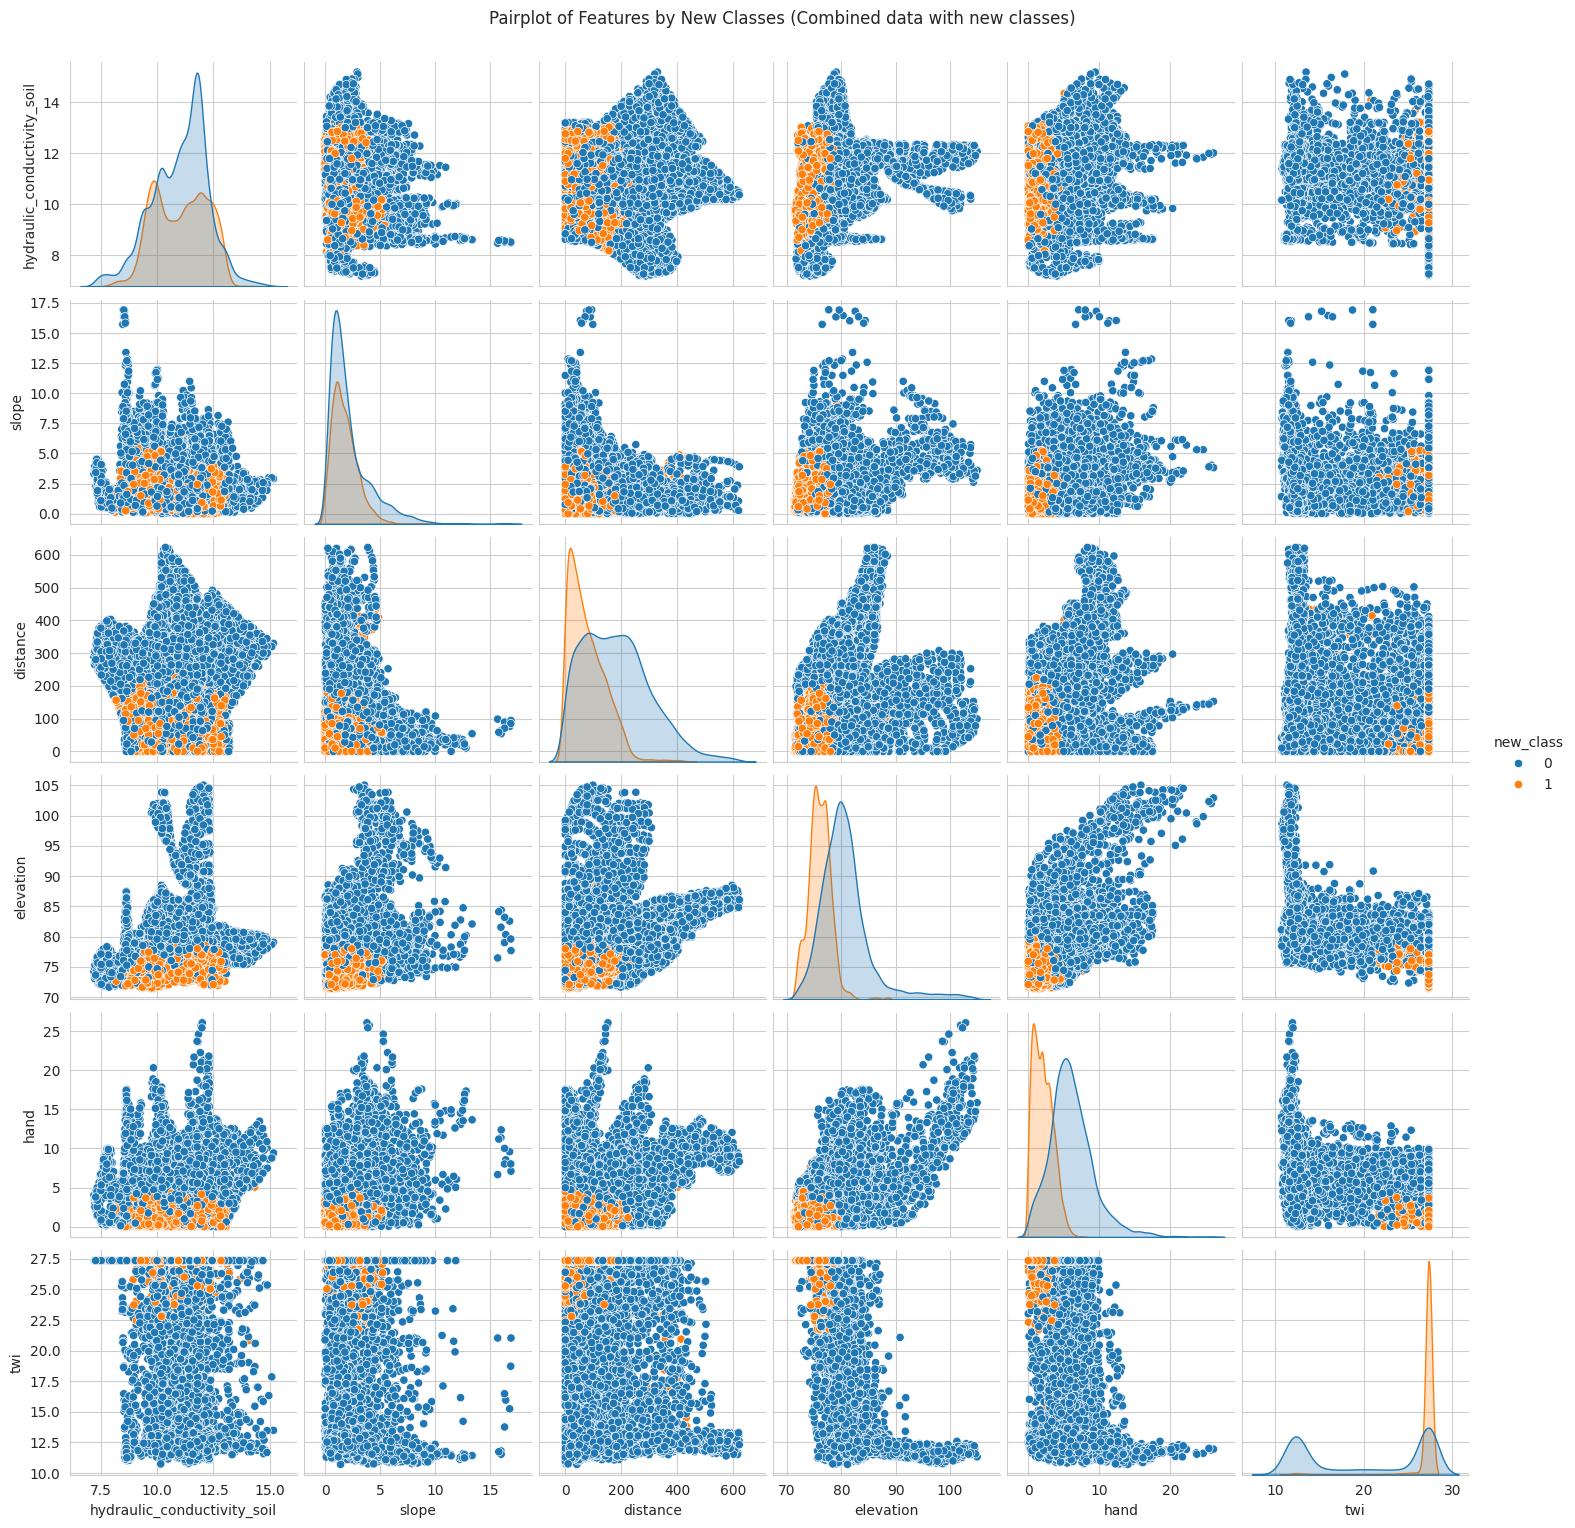

Plot saved as boxplots_by_new_classes.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

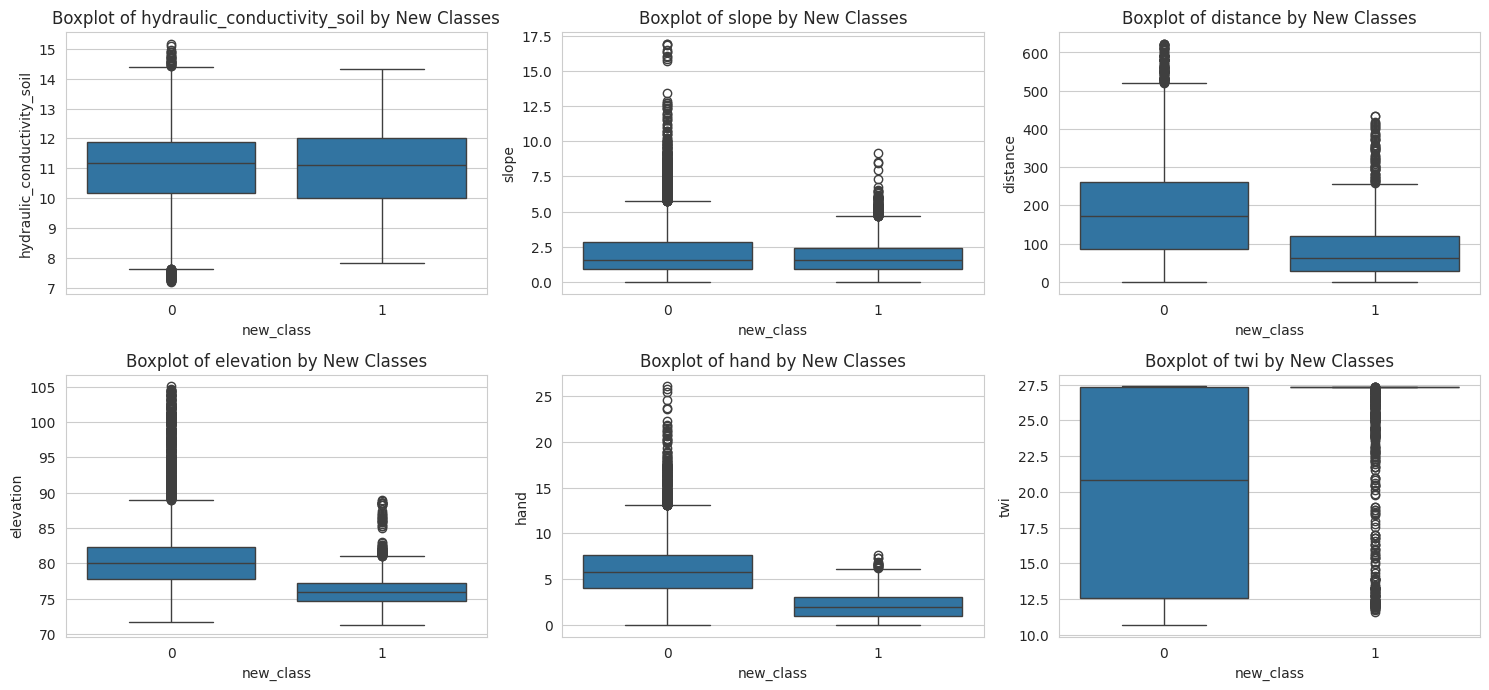

Pearson Correlation Matrix for all classes (Combined Data):


,hydraulic_conductivity_soil,slope,distance,elevation,hand,twi
hydraulic_conductivity_soil,1.000000,-0.095711,-0.076653,0.145274,-0.020056,-0.076081
slope,-0.095711,1.000000,-0.260265,0.197580,0.147391,-0.206552
distance,-0.076653,-0.260265,1.000000,0.263155,0.398377,-0.203825
elevation,0.145274,0.197580,0.263155,1.000000,0.631789,-0.709142
hand,-0.020056,0.147391,0.398377,0.631789,1.000000,-0.626936
twi,-0.076081,-0.206552,-0.203825,-0.709142,-0.626936,1.000000


Plot saved as correlation_matrix_all_classes.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

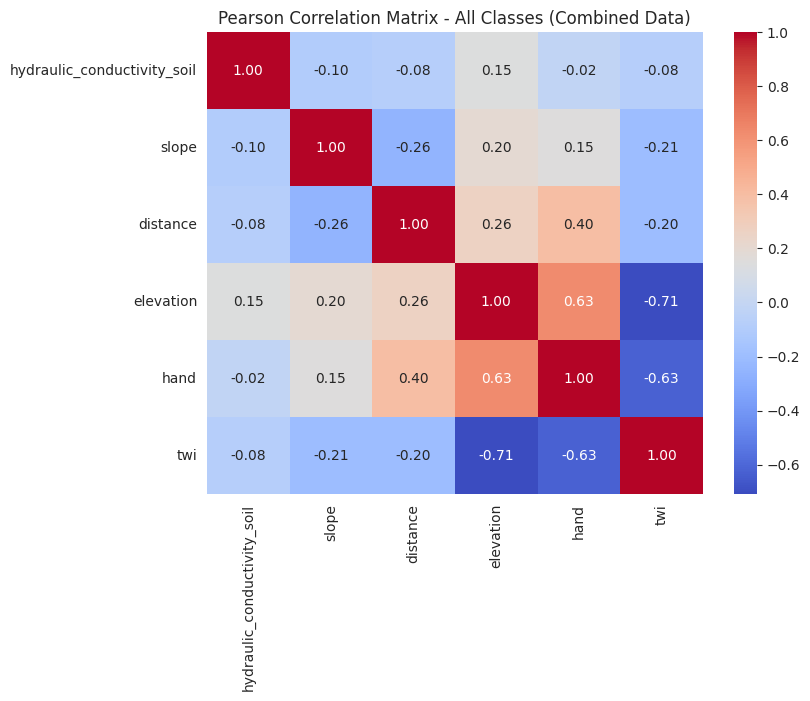

Matriz de Correlação de Pearson para a Classe 0:


,hydraulic_conductivity_soil,slope,distance,elevation,hand,twi
hydraulic_conductivity_soil,1.000000,-0.113899,-0.075110,0.159492,-0.020444,-0.117191
slope,-0.113899,1.000000,-0.399872,0.163108,0.087524,-0.167497
distance,-0.075110,-0.399872,1.000000,0.039790,0.167916,0.056025
elevation,0.159492,0.163108,0.039790,1.000000,0.506489,-0.621472
hand,-0.020444,0.087524,0.167916,0.506489,1.000000,-0.482422
twi,-0.117191,-0.167497,0.056025,-0.621472,-0.482422,1.000000


Plot saved as correlation_matrix_class_0.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

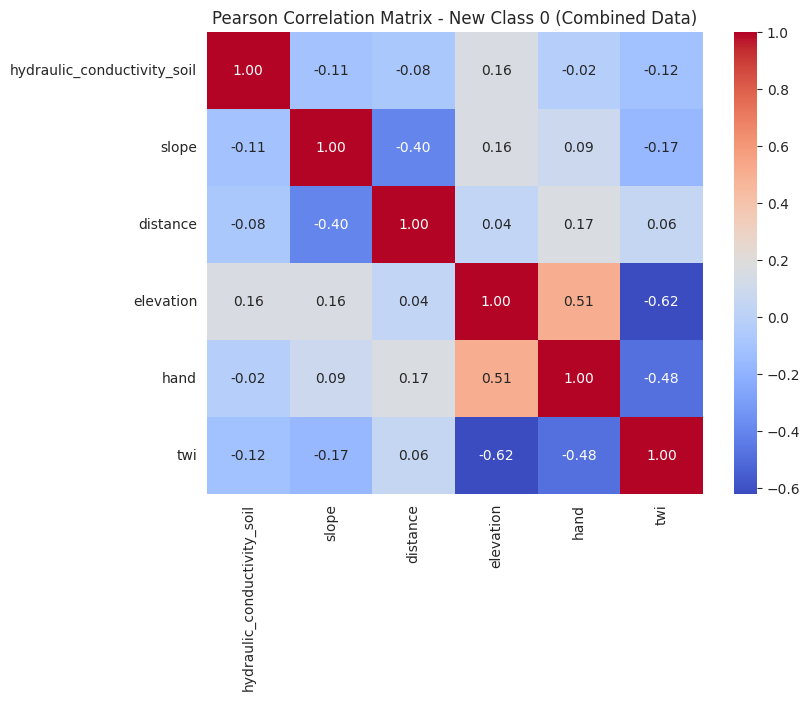


Matriz de Correlação de Pearson para a Classe 1:


,hydraulic_conductivity_soil,slope,distance,elevation,hand,twi
hydraulic_conductivity_soil,1.000000,-0.051236,-0.114418,0.264188,-0.023898,-0.011770
slope,-0.051236,1.000000,-0.134406,0.140740,0.130635,-0.221590
distance,-0.114418,-0.134406,1.000000,0.129193,0.255485,-0.137744
elevation,0.264188,0.140740,0.129193,1.000000,0.231380,-0.463754
hand,-0.023898,0.130635,0.255485,0.231380,1.000000,-0.206961
twi,-0.011770,-0.221590,-0.137744,-0.463754,-0.206961,1.000000


Plot saved as correlation_matrix_class_1.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

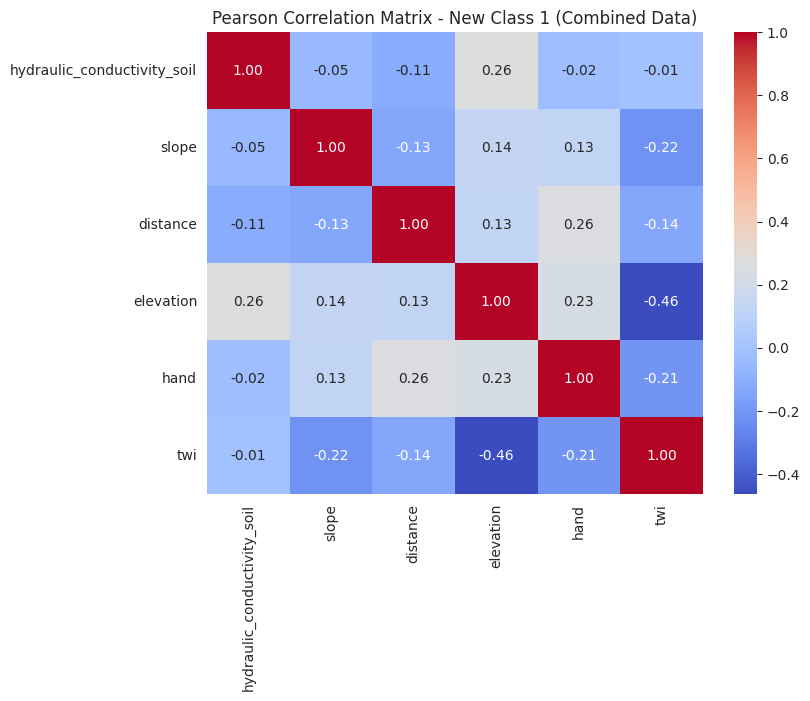

Basic Statistics for the entire dataset:


,hydraulic_conductivity_soil,slope,distance,elevation,hand,twi,new_class
count,14837.000000,14837.000000,14837.000000,14837.000000,14837.000000,14837.000000,14837.000000
mean,11.021150,2.033972,142.534305,78.889781,4.490177,22.770160,0.389701
std,1.211690,1.692253,114.725924,4.635925,3.226589,6.475763,0.487699
min,7.190892,0.000000,0.000000,71.331111,0.000000,10.706370,0.000000
25%,10.095165,0.908389,50.000000,75.863333,2.000000,14.753547,0.000000
50%,11.161931,1.564935,120.000000,78.008889,4.000000,27.356215,0.000000
75%,11.913193,2.613786,210.237960,80.900000,6.302031,27.356215,1.000000
max,15.175337,16.930172,622.896460,105.026667,26.066828,27.368484,1.000000



Basic Statistics for Class 0:


,hydraulic_conductivity_soil,slope,distance,elevation,hand,twi,new_class
count,9055.000000,9055.000000,9055.000000,9055.000000,9055.000000,9055.000000,9055.0
mean,11.014768,2.198806,183.552892,80.741575,6.051741,20.079105,0.0
std,1.242942,1.944245,120.542631,4.871198,3.101520,6.898794,0.0
min,7.190892,0.000000,0.000000,71.653333,0.000000,10.706370,0.0
25%,10.168043,0.899084,86.023253,77.810000,4.048650,12.554579,0.0
50%,11.187248,1.557874,171.172428,80.004444,5.717360,20.810220,0.0
75%,11.868310,2.838780,259.807550,82.286667,7.651298,27.356215,0.0
max,15.175337,16.930172,622.896460,105.026667,26.066828,27.368484,0.0



Basic Statistics for Class 1:


,hydraulic_conductivity_soil,slope,distance,elevation,hand,twi,new_class
count,5782.000000,5782.000000,5782.000000,5782.000000,5782.000000,5782.000000,5782.0
mean,11.031143,1.775832,78.296447,75.989747,2.044663,26.984533,1.0
std,1.161094,1.148837,65.256551,2.051712,1.360571,1.993620,0.0
min,7.827418,0.000000,0.000000,71.331111,0.000000,11.577346,1.0
25%,9.988536,0.926912,28.284271,74.697778,0.897472,27.356215,1.0
50%,11.116358,1.576562,63.245553,75.942778,1.898316,27.356215,1.0
75%,11.996655,2.425210,120.000000,77.237222,3.000000,27.356215,1.0
max,14.340008,9.151323,434.165867,88.912222,7.582260,27.356215,1.0


Variance Inflation Factor (VIF) for all features (Combined Data):


,feature,VIF
1,hydraulic_conductivity_soil,1.080160
2,slope,1.232927
3,distance,1.391953
4,elevation,2.393380
5,hand,2.123046
6,twi,2.279702


'VIF Value Interpretation\n1       No correlation with other variables\n1–5     Moderate correlation, generally acceptable\n> 5     Concerning multicollinearity\n> 10    Very high – should remove or combine variables'

In [85]:
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from google.colab import files # Import files for downloading

# Select relevant columns for analysis from combined_df
combined_data_for_analysis = combined_df.drop(columns=[col for col in combined_df.columns if col in ['system:index', 'usocobersolo_classification_2023', '.geo']])

# Translate feature names from Portuguese to English for consistency in plots and analysis
combined_data_for_analysis = combined_data_for_analysis.rename(columns={
    'elevacao': 'elevation',
    'distancia': 'distance',
    'declividade': 'slope',
    'condutividade_hidraulica_solo': 'hydraulic_conductivity_soil'
})

# Visualize distributions of numerical features
plt.figure(figsize=(15, 10)) # Ensure a new figure for this plot
combined_data_for_analysis.hist(bins=30, figsize=(15, 10)) # hist() creates its own figure, so previous line might be redundant if hist is called directly without a specific ax.
plt.suptitle('Distribution of Numerical Features (Combined data with new classes)', y=1.02)
plt.tight_layout()
plot_filename_hist = 'numerical_features_hist.png'
plt.savefig(plot_filename_hist, dpi=300)
print(f"Plot saved as {plot_filename_hist}")
files.download(plot_filename_hist)
plt.show()

# Visualize relationships between features using pairplot
sns.pairplot(combined_data_for_analysis, hue='new_class', diag_kind='kde')
plt.suptitle('Pairplot of Features by New Classes (Combined data with new classes)', y=1.02)
plot_filename_pairplot = 'pairplot_new_classes.png'
plt.savefig(plot_filename_pairplot, dpi=300)
print(f"Plot saved as {plot_filename_pairplot}")
files.download(plot_filename_pairplot)
plt.show()

# Visualize boxplots for each feature by class
plt.figure(figsize=(15, 10))
for i, col in enumerate(combined_data_for_analysis.columns[:-1]): # Exclude the target variable for individual boxplots
    plt.subplot(3, 3, i + 1) # Changed from 2x2 to 3x3 grid
    sns.boxplot(x='new_class', y=col, data=combined_data_for_analysis)
    plt.title(f'Boxplot of {col} by New Classes')
plt.tight_layout()
plot_filename_boxplots = 'boxplots_by_new_classes.png'
plt.savefig(plot_filename_boxplots, dpi=300)
print(f"Plot saved as {plot_filename_boxplots}")
files.download(plot_filename_boxplots)
plt.show()

# Calculate the Pearson correlation matrix for all classes in the combined data
combined_correlation_matrix_all = combined_data_for_analysis.drop(columns=['new_class']).corr(method='pearson')

# Display the correlation matrix for all classes
print("Pearson Correlation Matrix for all classes (Combined Data):")
display(combined_correlation_matrix_all)

# Visualize the correlation matrix for all classes as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(combined_correlation_matrix_all, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Pearson Correlation Matrix - All Classes (Combined Data)')
plot_filename_corr_all = 'correlation_matrix_all_classes.png'
plt.savefig(plot_filename_corr_all, dpi=300)
print(f"Plot saved as {plot_filename_corr_all}")
files.download(plot_filename_corr_all)
plt.show()


# Compute the Pearson correlation matrix for class 0
combined_data_correlation_matrix_class_0 = combined_data_for_analysis[combined_data_for_analysis['new_class'] == 0].drop(columns=['new_class']).corr(method='pearson')

# Display the correlation matrix for class 0
print("Pearson Correlation Matrix for Class 0:")
display(combined_data_correlation_matrix_class_0)

# Visualize the correlation matrix for class 0 as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(combined_data_correlation_matrix_class_0, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Pearson Correlation Matrix - New Class 0 (Combined Data)' )
plot_filename_corr_class0 = 'correlation_matrix_class_0.png'
plt.savefig(plot_filename_corr_class0, dpi=300)
print(f"Plot saved as {plot_filename_corr_class0}")
files.download(plot_filename_corr_class0)
plt.show()

# Compute the Pearson correlation matrix for class 1
combined_data_correlation_matrix_class_1 = combined_data_for_analysis[combined_data_for_analysis['new_class'] == 1].drop(columns=['new_class']).corr(method='pearson')

# Display the correlation matrix for class 1
print("\nPearson Correlation Matrix for Class 1:")
display(combined_data_correlation_matrix_class_1)

# Visualize the correlation matrix for class 1 as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(combined_data_correlation_matrix_class_1, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Pearson Correlation Matrix - New Class 1 (Combined Data)')
plot_filename_corr_class1 = 'correlation_matrix_class_1.png'
plt.savefig(plot_filename_corr_class1, dpi=300)
print(f"Plot saved as {plot_filename_corr_class1}")
files.download(plot_filename_corr_class1)
plt.show()

# Generate basic statistics for the entire combined_data_for_analysis DataFrame
print("Basic Statistics for the entire dataset:")
display(combined_data_for_analysis.describe())

# Generate basic statistics for Class 0
print("\nBasic Statistics for Class 0:")
display(combined_data_for_analysis[combined_data_for_analysis['new_class'] == 0].describe())

# Generate basic statistics for Class 1
print("\nBasic Statistics for Class 1:")
display(combined_data_for_analysis[combined_data_for_analysis['new_class'] == 1].describe())


# --- Variance Inflation Factor (VIF) Calculation ---

# All classes
# Select features for VIF calculation (exclude the target variable 'new_class')
X_vif_combined = combined_data_for_analysis.drop(columns=['new_class'])
# Add a constant to the features for VIF calculation
X_vif_combined = sm.add_constant(X_vif_combined)

# Calculate VIF for each feature in the combined data
vif_data_combined = pd.DataFrame()
vif_data_combined["feature"] = X_vif_combined.columns
vif_data_combined["VIF"] = [variance_inflation_factor(X_vif_combined.values, i)
                           for i in range(X_vif_combined.shape[1])]
# Remove the constant from the VIF table
vif_data_combined = vif_data_combined[vif_data_combined["feature"] != "const"]
print("Variance Inflation Factor (VIF) for all features (Combined Data):")
display(vif_data_combined)


'''VIF Value Interpretation
1       No correlation with other variables
1–5     Moderate correlation, generally acceptable
> 5     Concerning multicollinearity
> 10    Very high – should remove or combine variables'''

In [86]:
import pandas as pd
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier # GradientBoostingClassifier
from sklearn.neighbors import NearestCentroid # KNeighborsClassifier,
from sklearn.tree import DecisionTreeClassifier # Added DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, cohen_kappa_score
import json
from shapely.geometry import shape, Point
import numpy as np
from sklearn.cluster import SpectralClustering # Changed from KMeans to SpectralClustering
from sklearn.base import clone # Import clone

# 1. Prepare X, y and spatial groups from combined_df
# Extract coordinates from the '.geo' column
coordinates = []
valid_indices = []
for idx, geo_str in combined_df['.geo'].items():
    try:
        geo_dict = json.loads(geo_str)
        if geo_dict['type'] == 'Point':
            lon, lat = geo_dict['coordinates']
            coordinates.append([lon, lat])
            valid_indices.append(idx)
    except (json.JSONDecodeError, KeyError, TypeError):
        # Handle cases where .geo is not valid JSON or is not a Point
        pass

if not coordinates:
    raise ValueError("No valid geographic coordinates found in the combined_df['.geo'] column.")

coordinates_array = np.array(coordinates)
combined_df_spatial = combined_df.loc[valid_indices].copy() # Filter combined_df to keep only valid spatial data

# Create spatial groups using SpectralClustering on the coordinates
# The number of clusters can be chosen based on the desired number of spatial folds.
# We will increase it to give GroupKFold more flexibility to balance the folds.
n_spatial_clusters = 10
# Memory optimization: use affinity='nearest_neighbors' to avoid building a dense matrix.
# This is crucial for larger datasets and significantly reduces RAM consumption.
spectral_clustering = SpectralClustering(n_clusters=n_spatial_clusters, random_state=42, assign_labels='discretize', affinity='nearest_neighbors', n_neighbors=10) # Using SpectralClustering with memory optimization
combined_df_spatial['spatial_group'] = spectral_clustering.fit_predict(coordinates_array)

# Add the 'spatial_group' column back to the full combined_df
# This ensures the original DataFrame has the spatial fold identifier for each sample
train_val_full_combined_df = combined_df.merge(combined_df_spatial[['spatial_group']], left_index=True, right_index=True, how='left')

# Define features (X), target (y) and groups for spatial CV
features_to_drop = ['new_class', 'system:index', '.geo', 'spatial_group','usocobersolo_classification_2023']
X = combined_df_spatial.drop(columns=[col for col in features_to_drop if col in combined_df_spatial.columns])
y = combined_df_spatial['new_class']
groups = combined_df_spatial['spatial_group']

# Check whether X is empty after removing columns
if X.empty:
    raise ValueError("The features DataFrame (X) is empty after removing the specified columns. Check the column names.")

# Define model templates for cloning (with random_state where applicable)
model_templates = {
    'smileRandomForest': RandomForestClassifier(random_state=42),
    'smileCart': DecisionTreeClassifier(random_state=42),
    'minimumDistance': NearestCentroid()
}

# Spatial K-Fold Cross-Validation configuration
n_splits = 5 # Number of spatial folds

# Make sure the number of groups is sufficient for the number of splits
if groups.nunique() < n_splits:
    raise ValueError(f"The number of unique groups ({groups.nunique()}) is smaller than the number of splits ({n_splits}). Adjust n_spatial_clusters to be greater than or equal to n_splits.")

gkf = GroupKFold(n_splits=n_splits)

# Add lists to store y_val and y_proba from each fold
# Use the model_templates keys for the results dictionary
results = {name: {'accuracy': [], 'precision': [], 'recall': [], 'f1_score': [], 'roc_auc': [], 'cohen_kappa': [], 'y_val_folds': [], 'y_proba_folds': []} for name in model_templates}

print(f"Performing Spatial Cross-Validation with {n_splits} folds...")

for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups=groups)): # Changed X to use the original before scaling
    X_train_unscaled, X_val_unscaled = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # Scale features within the fold for KNN, skipping for tree-based models
    fold_scaler = StandardScaler()
    X_train_scaled = fold_scaler.fit_transform(X_train_unscaled)
    X_val_scaled = fold_scaler.transform(X_val_unscaled)

    X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train_unscaled.index)
    X_val_scaled_df = pd.DataFrame(X_val_scaled, columns=X.columns, index=X_val_unscaled.index)


    print(f"\n--- Fold {fold + 1}/{n_splits} ---")
    print(f"Training samples: {len(X_train_unscaled)}, Validation samples: {len(X_val_unscaled)}")
    print(f"Group distribution in Training: {groups.iloc[train_idx].value_counts().to_dict()}")
    print(f"Group distribution in Validation: {groups.iloc[val_idx].value_counts().to_dict()}")
    print(f"Target distribution in Training: {y_train.value_counts().to_dict()}")
    print(f"Target distribution in Validation: {y_val.value_counts().to_dict()}")

    # Ensure that all target classes (0 and 1) are present in the validation sets for the evaluation metrics
    if len(y_val.unique()) < 2 or len(X_val_unscaled) == 0:
        print(f"Skipping evaluation for Fold {fold + 1} due to insufficient target classes in the validation set or an empty validation set.")
        for model_name in model_templates:
            results[model_name]['accuracy'].append(np.nan)
            results[model_name]['precision'].append(np.nan)
            results[model_name]['recall'].append(np.nan)
            results[model_name]['f1_score'].append(np.nan)
            results[model_name]['roc_auc'].append(np.nan)
            results[model_name]['cohen_kappa'].append(np.nan)
            results[model_name]['y_val_folds'].append(y_val) # Store even if empty or single class
            results[model_name]['y_proba_folds'].append(None) # Store None for proba if not applicable
        continue

    for name, model_template in model_templates.items(): # Iterate over the templates
        print(f"  Training {name}...")

        model = clone(model_template) # Clone the template to get a new instance for the fold

        if name in ['minimumDistance']:
            model.fit(X_train_scaled_df, y_train)
            y_pred = model.predict(X_val_scaled_df)
            # Fallback for models without predict_proba, or if there are not enough samples for both classes
            if hasattr(model, 'predict_proba') and len(y_val.unique()) == 2:
                y_proba = model.predict_proba(X_val_scaled_df)[:, 1]
            else:
                y_proba = None # Placeholder value, AUC will be NaN
        else:
            model.fit(X_train_unscaled, y_train)
            y_pred = model.predict(X_val_unscaled)
            # Fallback for models without predict_proba, or if there are not enough samples for both classes
            if hasattr(model, 'predict_proba') and len(y_val.unique()) == 2:
                y_proba = model.predict_proba(X_val_unscaled)[:, 1]
            else:
                y_proba = None # Placeholder value, AUC will be NaN

        acc = accuracy_score(y_val, y_pred)
        prec = precision_score(y_val, y_pred, zero_division=0)
        rec = recall_score(y_val, y_pred, zero_division=0)
        f1 = f1_score(y_val, y_pred, zero_division=0)
        kappa = cohen_kappa_score(y_val, y_pred) # Cohen's Kappa computation

        # ROC AUC requires at least two classes in y_true and y_score
        try:
            # Only calculate AUC if y_proba is not None and contains predictions
            if y_proba is not None and len(y_proba) > 0 and len(y_val.unique()) == 2:
                auc = roc_auc_score(y_val, y_proba)
            else:
                auc = np.nan # If no valid proba or single class, AUC cannot be calculated
        except ValueError:
            auc = np.nan # If only one class is present, AUC cannot be computed

        results[name]['accuracy'].append(acc)
        results[name]['precision'].append(prec)
        results[name]['recall'].append(rec)
        results[name]['f1_score'].append(f1)
        results[name]['roc_auc'].append(auc)
        results[name]['cohen_kappa'].append(kappa)
        results[name]['y_val_folds'].append(y_val)
        results[name]['y_proba_folds'].append(y_proba)

        print(f"    {name} - Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1-score: {f1:.4f}, ROC AUC: {auc:.4f}, Kappa: {kappa:.4f}")

print("\n--- Spatial Cross-Validation Results ---")
for name, metrics in results.items():
    print(f"\nModel: {name}")
    print(f"  Mean Accuracy: {np.nanmean(metrics['accuracy']):.4f} (+/- {np.nanstd(metrics['accuracy']):.4f})")
    print(f"  Mean Precision: {np.nanmean(metrics['precision']):.4f} (+/- {np.nanstd(metrics['precision']):.4f})")
    print(f"  Mean Recall: {np.nanmean(metrics['recall']):.4f} (+/- {np.nanstd(metrics['recall']):.4f})")
    print(f"  Mean F1-score: {np.nanmean(metrics['f1_score']):.4f} (+/- {np.nanstd(metrics['f1_score']):.4f})")
    print(f"  Mean ROC AUC: {np.nanmean(metrics['roc_auc']):.4f} (+/- {np.nanstd(metrics['roc_auc']):.4f})")
    print(f"  Mean Cohen's Kappa: {np.nanmean(metrics['cohen_kappa']):.4f} (+/- {np.nanstd(metrics['cohen_kappa']):.4f})")

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


Realizando Validação Cruzada Espacial com 5 folds...

--- Fold 1/5 ---
Amostras de Treino: 12111, Amostras de Validação: 2726
Distribuição de grupos no Treino: {4: 2041, 6: 1597, 2: 1434, 9: 1423, 7: 1306, 8: 1292, 3: 1040, 5: 1002, 1: 976}
Distribuição de grupos na Validação: {0: 2726}
Distribuição do target no Treino: {0: 7409, 1: 4702}
Distribuição do target na Validação: {0: 1646, 1: 1080}
  Treinando smileRandomForest...
    smileRandomForest - Acurácia: 0.9347, Precisão: 0.9199, Recall: 0.9148, F1-score: 0.9174, ROC AUC: 0.9680, Kappa: 0.8634
  Treinando smileCart...
    smileCart - Acurácia: 0.9024, Precisão: 0.8521, Recall: 0.9120, F1-score: 0.8810, ROC AUC: 0.9041, Kappa: 0.7985
  Treinando minimumDistance...
    minimumDistance - Acurácia: 0.8547, Precisão: 0.7412, Recall: 0.9731, F1-score: 0.8415, ROC AUC: 0.9397, Kappa: 0.7119

--- Fold 2/5 ---
Amostras de Treino: 11794, Amostras de Validação: 3043
Distribuição de grupos no Treino: {0: 2726, 6: 1597, 2: 1434, 9: 1423, 7: 13

Plot saved as spatial_distribution_train_val.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

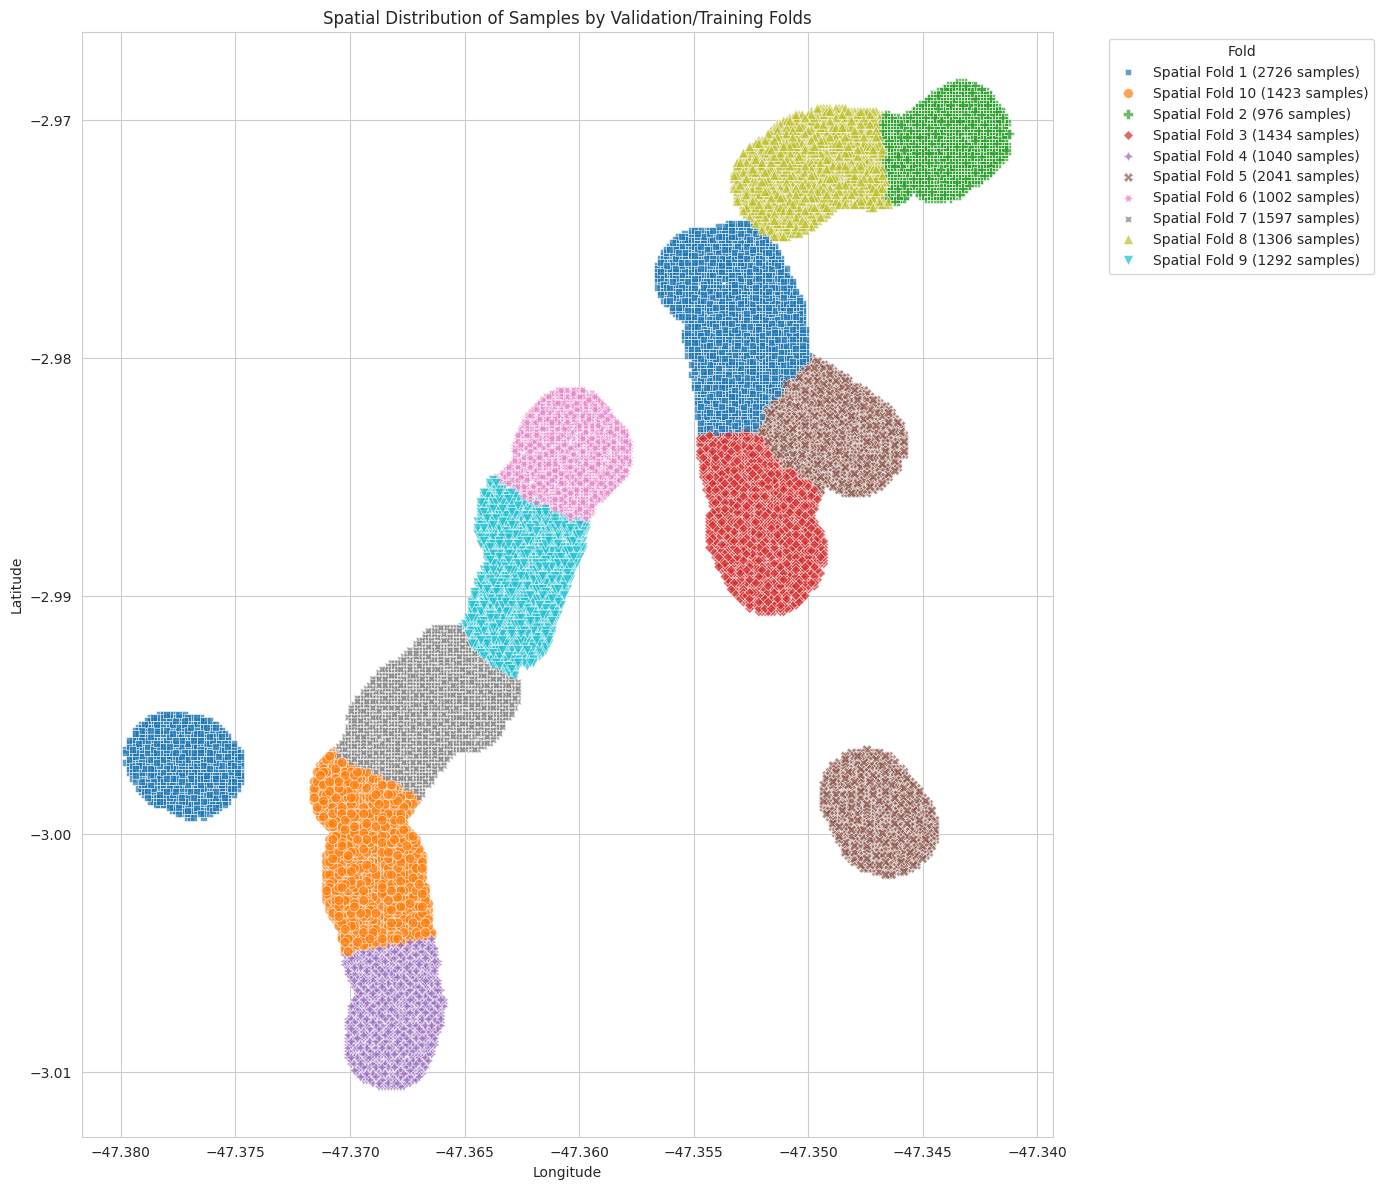

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns
import json
import pandas as pd
from google.colab import files # Import files for downloading

# Function to extract lat/lon from the .geo field
def extract_lat_lon(geo_str):
    try:
        geo_dict = json.loads(geo_str)
        if geo_dict['type'] == 'Point':
            lon, lat = geo_dict['coordinates']
            return pd.Series({'longitude': lon, 'latitude': lat})
    except (json.JSONDecodeError, KeyError, TypeError):
        return pd.Series({'longitude': None, 'latitude': None})

# --- Prepare Training/Validation data (combined_df) ---
combined_df_plot_train_val = pd.DataFrame()
# Use combined_df_spatial directly, since it already contains valid 'spatial_group' and '.geo'
if 'combined_df_spatial' in locals() and '.geo' in combined_df_spatial.columns:
    temp_plot_df = combined_df_spatial[['spatial_group', '.geo']].copy()

    # Extract coordinates and merge with temp_plot_df
    coords_df = temp_plot_df['.geo'].apply(extract_lat_lon)
    temp_plot_df = temp_plot_df.merge(coords_df, left_index=True, right_index=True, how='left')

    # Remove rows where latitude or longitude could not be extracted
    combined_df_plot_train_val = temp_plot_df.dropna(subset=['latitude', 'longitude']).copy()

    # Ensure 'spatial_group' exists and create 'spatial_fold_type'
    # With the new logic, this condition should always be true if combined_df_spatial had the column.
    if 'spatial_group' in combined_df_plot_train_val.columns:
        # Create a distinct label for each spatial group, adjusting the numbering to start from 1
        combined_df_plot_train_val['spatial_fold_type'] = combined_df_plot_train_val['spatial_group'].astype(str).apply(lambda x: f'Spatial Fold {int(x) + 1}')
    else:
        # This section is only reached if there is an unexpected problem in the previous logic
        combined_df_plot_train_val['spatial_fold_type'] = 'Training/Validation Data (No Spatial Folds)'
        print("Attention: The 'spatial_group' column was not found to generate distinct folds.")
else:
    print("The DataFrame 'combined_df_spatial' or the '.geo' column was not found. Training/Validation data cannot be plotted.")

# --- Generate Plot ---
if not combined_df_plot_train_val.empty:
    final_plot_df = combined_df_plot_train_val

    plt.figure(figsize=(14, 12))

    # Compute the number of samples per fold and create new labels for the legend
    fold_counts = final_plot_df['spatial_fold_type'].value_counts()
    new_fold_labels_map = {}
    for fold_type in sorted(final_plot_df['spatial_fold_type'].unique()):
        count = fold_counts.get(fold_type, 0)
        new_fold_labels_map[fold_type] = f"{fold_type} ({count} samples)"

    # Apply the new labels to the DataFrame for use in the scatterplot
    final_plot_df['spatial_fold_type_with_count'] = final_plot_df['spatial_fold_type'].map(new_fold_labels_map)

    # Define the unique labels with counts for the palette and markers
    unique_fold_types_with_count = sorted(final_plot_df['spatial_fold_type_with_count'].unique())

    # Create a dynamic palette for the spatial folds.
    # Use a distinct color for each fold.
    num_unique_spatial_folds_actual = len(unique_fold_types_with_count)
    if num_unique_spatial_folds_actual > 10:
        train_val_colors = sns.color_palette('viridis', n_colors=num_unique_spatial_folds_actual).as_hex()
    else:
        train_val_colors = sns.color_palette('tab10', n_colors=num_unique_spatial_folds_actual).as_hex()

    custom_palette = {}
    for i, fold_type_str_with_count in enumerate(unique_fold_types_with_count):
        custom_palette[fold_type_str_with_count] = train_val_colors[i]

    # Define a default marker for all points
    markers_dict = {fold_type_with_count: 'o' for fold_type_with_count in unique_fold_types_with_count}

    # Define the legend order using the new labels
    hue_order = unique_fold_types_with_count

    sns.scatterplot(
        data=final_plot_df,
        x='longitude',
        y='latitude',
        hue='spatial_fold_type_with_count',
        palette=custom_palette,
        style='spatial_fold_type_with_count',
        markers=True,
        s=50,
        alpha=0.7,
        hue_order=hue_order
    )
    plt.title('Spatial Distribution of Samples by Validation/Training Folds')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.legend(title='Fold', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True)
    plt.tight_layout()

    # Save the plot with 300 DPI
    plot_filename_train_val = 'spatial_distribution_train_val.png'
    plt.savefig(plot_filename_train_val, dpi=300)
    print(f"Plot saved as {plot_filename_train_val}")
    files.download(plot_filename_train_val)

    plt.show()
else:
    print("No Training/Validation data available to plot.")

Total de amostras no conjunto de teste: 2619
Plot saved as spatial_distribution_test_data.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

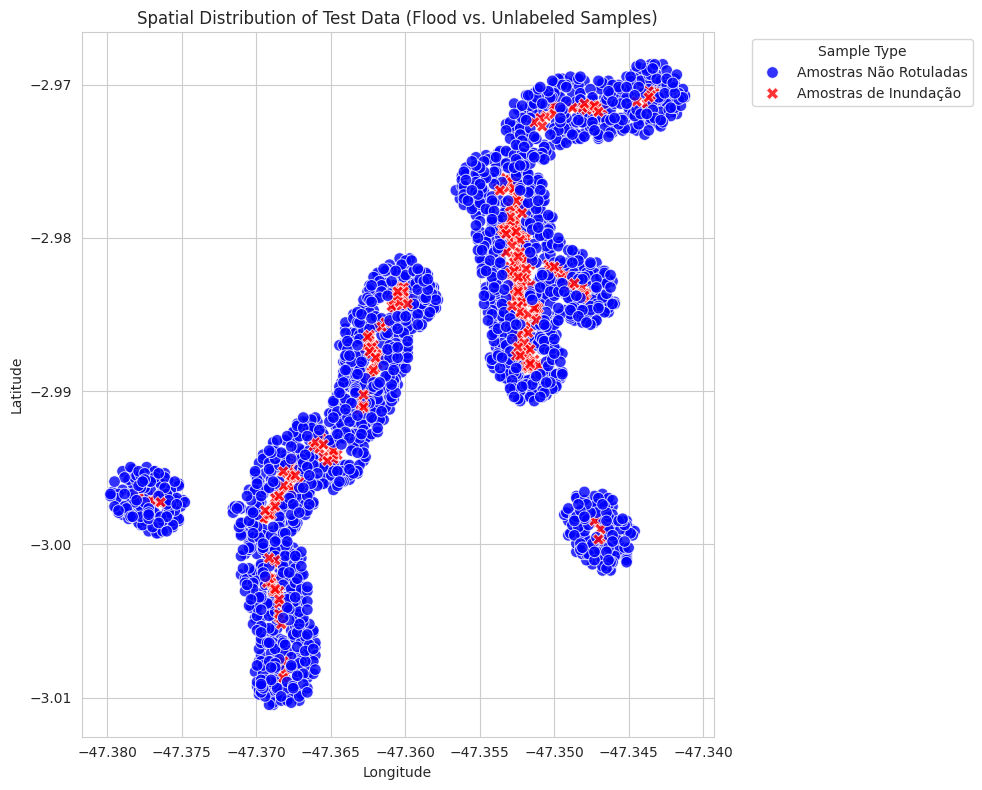

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns
import json
import pandas as pd
from google.colab import files # Import files for downloading

# --- Prepare data_test_full for plotting ---
# Ensure data_test_full is available. It is generated in cell 7Fb7vf9K7T7C.
if 'data_test_full' in locals() and '.geo' in data_test_full.columns:
    # Include the 'classes' column to differentiate flood vs. unlabeled samples
    data_test_full_plot_df = data_test_full[['.geo', 'classes']].copy()

    # Extract coordinates and merge
    coords_test_df = data_test_full_plot_df['.geo'].apply(extract_lat_lon)
    data_test_full_plot_df = data_test_full_plot_df.merge(coords_test_df, left_index=True, right_index=True, how='left')

    # Remove rows where latitude or longitude could not be extracted
    data_test_full_plot_df = data_test_full_plot_df.dropna(subset=['latitude', 'longitude']).copy()

    # Create a new column to categorize samples based on their 'classes' label
    # 1 for flood samples, 0 for unlabeled samples
    data_test_full_plot_df['sample_type'] = data_test_full_plot_df['classes'].map({
        1: 'Flood Samples',
        0: 'Unlabeled Samples'
    })

    # Add total count for context, although it won't be used for hue/style
    test_data_count = len(data_test_full_plot_df)
    print(f"Total samples in the test set: {test_data_count}")

else:
    data_test_full_plot_df = pd.DataFrame()
    print("The DataFrame 'data_test_full' or the '.geo' column was not found. Test data cannot be plotted.")

# --- Generate Plot ---
if not data_test_full_plot_df.empty:
    plt.figure(figsize=(10, 8))

    sns.scatterplot(
        data=data_test_full_plot_df,
        x='longitude',
        y='latitude',
        hue='sample_type', # Use the new 'sample_type' for coloring
        palette={'Flood Samples': 'red', 'Unlabeled Samples': 'blue'}, # Custom palette
        style='sample_type', # Use 'sample_type' for marker styles
        markers={'Flood Samples': 'X', 'Unlabeled Samples': 'o'},  # Custom markers
        s=70, # Slightly larger size for visibility
        alpha=0.8
    )
    plt.title('Spatial Distribution of Test Data (Flood vs. Unlabeled Samples)') # Updated title to English
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.legend(title='Sample Type', bbox_to_anchor=(1.05, 1), loc='upper left') # Updated legend title to English
    plt.grid(True)
    plt.tight_layout()

    # Save the plot with 300 DPI
    plot_filename = 'spatial_distribution_test_data.png'
    plt.savefig(plot_filename, dpi=300)
    print(f"Plot saved as {plot_filename}")
    files.download(plot_filename)

    plt.show()
else:
    print("No Test data available to plot.")

Generating ROC Curves for each model...
ROC Curves plot saved as roc_curves.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

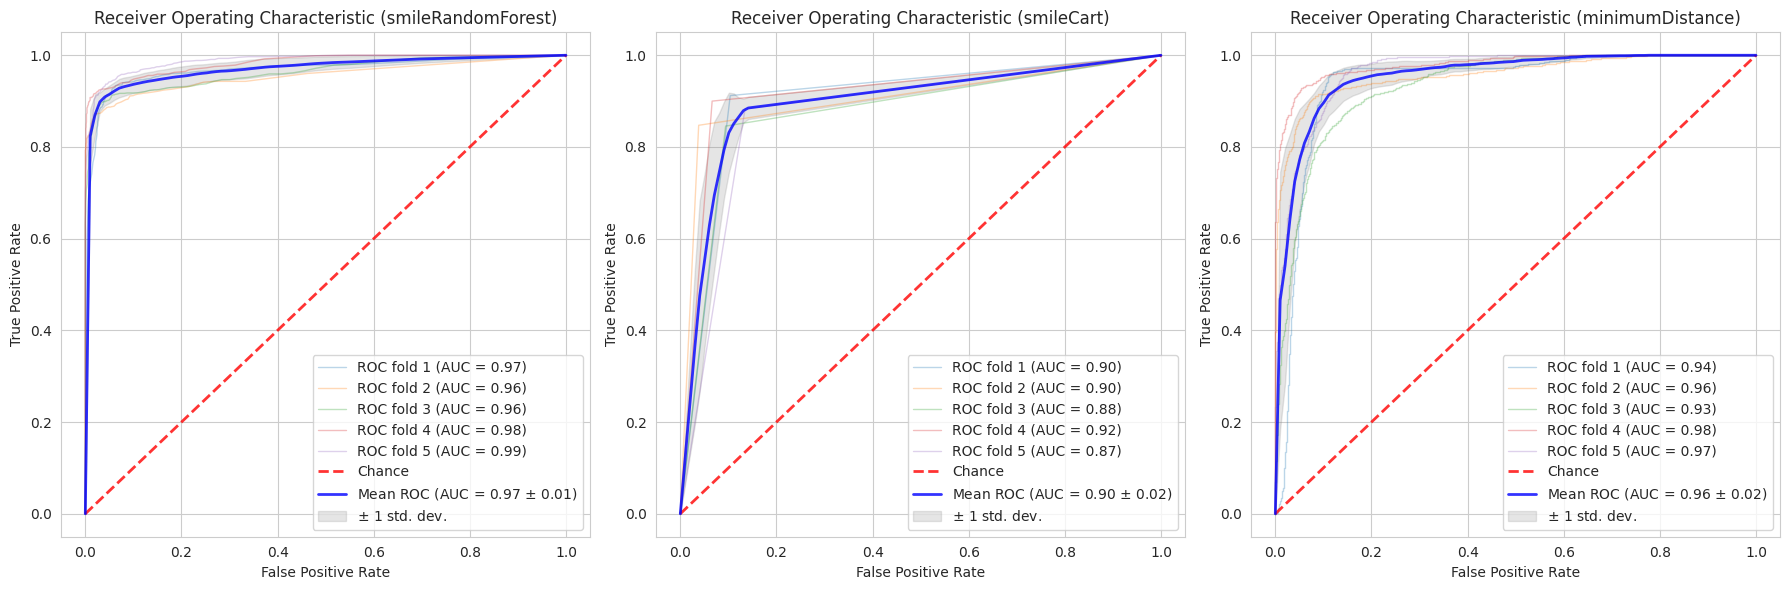

ROC Curve generation complete.

Generating Confusion Matrices for each model (side-by-side)...
Combined Confusion Matrices plot saved as confusion_matrices_all_models.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

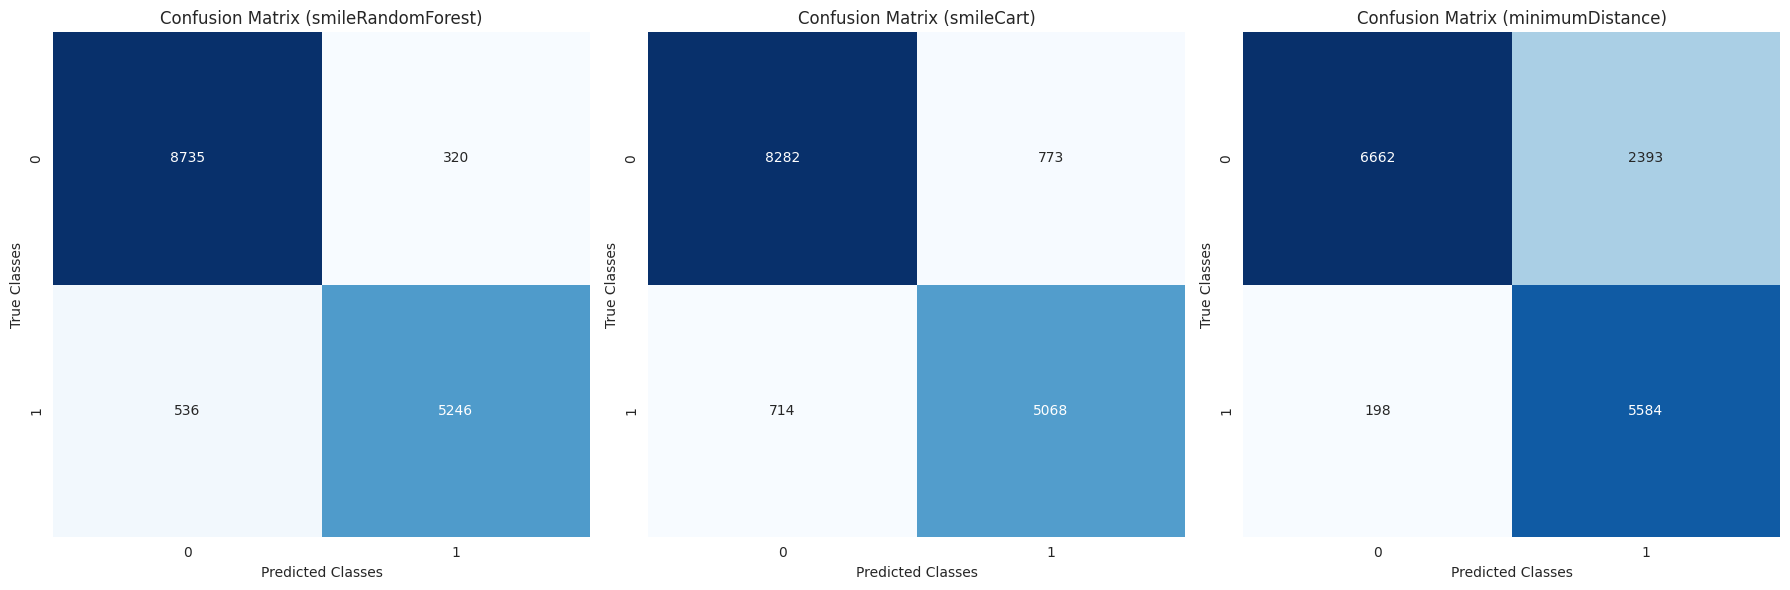

Confusion Matrix generation complete for all models.


In [93]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import RocCurveDisplay, roc_curve, auc, confusion_matrix
import numpy as np
from google.colab import files # Import files for downloading

# Configure plot style
sns.set_style("whitegrid")

print("Generating ROC Curves for each model...")

plt.figure(figsize=(18, 6))

# Iterate over each model to plot its ROC curves
for i, (model_name, model_results) in enumerate(results.items()):
    ax = plt.subplot(1, len(results), i + 1)

    tprs = []
    aucs = []
    mean_fpr = np.linspace(0, 1, 100)

    # Plot ROC curve for each fold
    for fold_idx in range(len(model_results['y_val_folds'])):
        y_val = model_results['y_val_folds'][fold_idx]
        y_proba = model_results['y_proba_folds'][fold_idx]

        # Skip if y_val does not contain both classes or is empty
        if len(np.unique(y_val)) < 2 or len(y_val) == 0:
            continue

        # If y_proba is None, ROC AUC cannot be calculated for this fold
        if y_proba is None:
            print(f"Warning: y_proba is None for {model_name}, Fold {fold_idx + 1}. Skipping ROC plot for this fold.")
            continue # Skip ROC plot for this fold if no proba

        fpr, tpr, _ = roc_curve(y_val, y_proba)
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        tprs.append(interp_tpr)
        aucs.append(auc(fpr, tpr))

        ax.plot(fpr, tpr, lw=1, alpha=0.3,
                label=f'ROC fold {fold_idx + 1} (AUC = {aucs[-1]:.2f})')

    # Plot random classifier line
    ax.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Chance', alpha=0.8)

    if tprs:
        # Calculate and plot mean ROC
        mean_tpr = np.mean(tprs, axis=0)
        mean_tpr[-1] = 1.0
        mean_auc = np.mean(aucs)
        std_auc = np.std(aucs)
        ax.plot(mean_fpr, mean_tpr, color='b',
                label=r'Mean ROC (AUC = %0.2f $\pm$ %0.2f)' % (mean_auc, std_auc),
                lw=2, alpha=.8)

        # Calculate and plot standard deviation around the mean ROC
        std_tpr = np.std(tprs, axis=0)
        tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
        tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
        ax.fill_between(mean_fpr, tprs_lower, tprs_upper, color='grey', alpha=.2,
                        label=r'$\pm$ 1 std. dev.')

    ax.set(xlim=[-0.05, 1.05], ylim=[-0.05, 1.05],
           title=f'Receiver Operating Characteristic ({model_name})')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc="lower right")
    ax.grid(True)

plt.tight_layout()

# Save the plot with 300 DPI
plot_filename_roc = 'roc_curves.png'
plt.savefig(plot_filename_roc, dpi=300)
print(f"ROC Curves plot saved as {plot_filename_roc}")
files.download(plot_filename_roc)

plt.show()

print("ROC Curve generation complete.")

print("\nGenerating Confusion Matrices for each model (side-by-side)...")

# Determine the number of models to plot for confusion matrices
num_models = len(results)

# Create a single figure with subplots for all confusion matrices
fig_cm, axes_cm = plt.subplots(1, num_models, figsize=(6 * num_models, 6))

# If there's only one model, axes_cm might not be an array, handle this case
if num_models == 1:
    axes_cm = [axes_cm]

# Loop through each model to generate and plot confusion matrices
for i, (model_name, model_metrics) in enumerate(results.items()):
    all_y_true = []
    all_y_pred_derived = [] # Predicted labels derived from probabilities

    # Aggregate y_val and y_proba for all valid folds for the current model
    for fold_idx in range(len(model_metrics['y_val_folds'])):
        y_val_fold = model_metrics['y_val_folds'][fold_idx]
        y_proba_fold = model_metrics['y_proba_folds'][fold_idx]

        # Check if the fold results are valid for CM calculation
        # Need y_proba to derive y_pred, and y_val_fold must have at least 2 unique classes.
        if y_proba_fold is not None and len(y_proba_fold) > 0 and len(np.unique(y_val_fold)) >= 2:
            all_y_true.append(y_val_fold)
            # Derive predicted classes from probabilities using a 0.5 threshold
            y_pred_from_proba = (y_proba_fold >= 0.5).astype(int)
            all_y_pred_derived.append(y_pred_from_proba)

    if all_y_true and all_y_pred_derived:
        # Concatenate all valid fold results
        all_y_true_combined = np.concatenate(all_y_true)
        all_y_pred_combined = np.concatenate(all_y_pred_derived)

        # Ensure combined arrays still have at least two classes after aggregation
        if len(np.unique(all_y_true_combined)) < 2 or len(np.unique(all_y_pred_combined)) < 2:
            print(f"Skipping Confusion Matrix for {model_name}: Insufficient classes in combined true or predicted labels after deriving from probabilities for any valid fold.")
            # Hide the empty subplot if it exists
            if num_models > 0 and i < num_models:
                axes_cm[i].axis('off')
            continue

        # Calculate the confusion matrix
        cm = confusion_matrix(all_y_true_combined, all_y_pred_combined)

        # Plot Confusion Matrix on the respective subplot
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                    xticklabels=[0, 1], yticklabels=[0, 1], ax=axes_cm[i], linewidths=0)
        axes_cm[i].set_xlabel('Predicted Classes')
        axes_cm[i].set_ylabel('True Classes')
        axes_cm[i].set_title(f'Confusion Matrix ({model_name})')
    else:
        print(f"Warning: No valid probabilities or true labels found for {model_name} across any fold to generate Confusion Matrix. This might be due to the model not providing probabilities (e.g., NearestCentroid) or insufficient classes in validation sets.")
        # Hide the empty subplot if it exists
        if num_models > 0 and i < num_models:
            axes_cm[i].axis('off')

plt.tight_layout()

# Save the combined plot with 300 DPI
plot_filename_all_cm = 'confusion_matrices_all_models.png'
plt.savefig(plot_filename_all_cm, dpi=300)
print(f"Combined Confusion Matrices plot saved as {plot_filename_all_cm}")
files.download(plot_filename_all_cm)

plt.show()

print("Confusion Matrix generation complete for all models.")

In [90]:
import numpy as np
import pandas as pd # Import pandas for DataFrame creation

best_model = None
highest_model_score = -1 # Initialize with a low score

print("Model Analysis:\n")

# Prepare data for the comparison table
model_comparison_data = []

for name, metrics in results.items():
    mean_accuracy = np.nanmean(metrics['accuracy'])
    mean_precision = np.nanmean(metrics['precision'])
    mean_recall = np.nanmean(metrics['recall'])
    mean_f1_score = np.nanmean(metrics['f1_score'])
    mean_roc_auc = np.nanmean(metrics['roc_auc'])
    mean_cohen_kappa = np.nanmean(metrics['cohen_kappa'])

    std_accuracy = np.nanstd(metrics['accuracy'])
    std_precision = np.nanstd(metrics['precision'])
    std_recall = np.nanstd(metrics['recall'])
    std_f1_score = np.nanstd(metrics['f1_score'])
    std_roc_auc = np.nanstd(metrics['roc_auc'])
    std_cohen_kappa = np.nanstd(metrics['cohen_kappa'])

    model_comparison_data.append({
        'Model': name,
        'Accuracy (Mean)': f'{mean_accuracy:.4f}',
        'Accuracy (Std)': f'({std_accuracy:.4f})',
        'Precision (Mean)': f'{mean_precision:.4f}',
        'Precision (Std)': f'({std_precision:.4f})',
        'Recall (Mean)': f'{mean_recall:.4f}',
        'Recall (Std)': f'({std_recall:.4f})',
        'F1-score (Mean)': f'{mean_f1_score:.4f}',
        'F1-score (Std)': f'({std_f1_score:.4f})',
        'ROC AUC (Mean)': f'{mean_roc_auc:.4f}',
        'ROC AUC (Std)': f'({std_roc_auc:.4f})',
        'Cohen\'s Kappa (Mean)': f'{mean_cohen_kappa:.4f}',
        'Cohen\'s Kappa (Std)': f'({std_cohen_kappa:.4f})'
    })

    print(f"Model: {name}")
    print(f"  Mean Accuracy: {mean_accuracy:.4f}")
    print(f"  Mean Precision: {mean_precision:.4f}")
    print(f"  Mean Recall: {mean_recall:.4f}")
    print(f"  Mean F1-score: {mean_f1_score:.4f}")
    print(f"  Mean ROC AUC: {mean_roc_auc:.4f}")
    print(f"  Mean Cohen's Kappa: {mean_cohen_kappa:.4f}\n")

    # New selection criterion: Prioritize F1-score and Recall with weights
    # Formula: 0.4 * mean_f1_score + 0.4 * mean_roc_auc + 0.2 * mean_cohen_kappa
    # Handle NaN values by converting them to 0 for scoring, so models with missing metrics aren't unfairly penalized
    # or simply skipped if all other models have some valid score.
    current_f1 = 0 if np.isnan(mean_f1_score) else mean_f1_score
    current_roc_auc = 0 if np.isnan(mean_roc_auc) else mean_roc_auc
    current_kappa = 0 if np.isnan(mean_cohen_kappa) else mean_cohen_kappa

    model_score = (0.4 * current_f1 + 0.4 * current_roc_auc + 0.2 * current_kappa)

    if model_score > highest_model_score:
        highest_model_score = model_score
        best_model = name

# Create and display the DataFrame
print("--- Model Comparison Table ---")
model_comparison_df = pd.DataFrame(model_comparison_data)
display(model_comparison_df)


print(f"--------------------------------------------------")
print(f"The best identified model is: {best_model}\n")

if best_model:
    metrics_best_model = results[best_model]
    mean_acc = np.nanmean(metrics_best_model['accuracy'])
    mean_prec = np.nanmean(metrics_best_model['precision'])
    mean_rec = np.nanmean(metrics_best_model['recall'])
    mean_f1 = np.nanmean(metrics_best_model['f1_score'])
    mean_auc = np.nanmean(metrics_best_model['roc_auc'])
    mean_kappa = np.nanmean(metrics_best_model['cohen_kappa'])

    print(f"Why {best_model} is the best:")
    print(f"  - **Weighted Score**: {best_model} achieved the highest score of {highest_model_score:.4f} using the custom metric (0.4 * F1-score + 0.4 * ROC AUC + 0.2 * Cohen's Kappa), which is crucial for flood mapping problems where detecting false negatives is vital.")
    print(f"  - **Mean ROC AUC**: At {mean_auc:.4f}, {best_model} shows an excellent ability to distinguish between the positive and negative classes at different thresholds, being a robust performance indicator for classification problems, especially with imbalanced data.")
    print(f"  - **Mean F1-score**: Reaching {mean_f1:.4f}, this model presents a good balance between precision (proportion of true positives among all predicted positives) and recall (proportion of true positives among all actual positives). This is crucial when both metrics are important, as in flood detection.")
    print(f"  - **Mean Cohen's Kappa**: With a value of {mean_kappa:.4f}, {best_model} shows substantial agreement with reality, accounting for the agreement that would occur by chance. It is a valuable metric to assess model robustness beyond simple accuracy.")
    print(f"  - **Mean Precision**: At {mean_prec:.4f}, it minimizes false positives, which can be important to avoid unnecessary alarms.")
    print(f"  - **Mean Recall**: At {mean_rec:.4f}, it manages to identify most of the actual positive cases, which is vital so as not to miss flood events.")
    print(f"  - **Mean Accuracy**: Although it is not the only metric, an accuracy of {mean_acc:.4f} reinforces the model's good overall performance.")
    print(f"\nIn summary, {best_model} stands out for its balanced and robust performance across several metrics important for the problem at hand, indicating a high predictive and generalization capability.")

Análise dos Modelos:

Modelo: smileRandomForest
  Acurácia Média: 0.9436
  Precisão Média: 0.9484
  Recall Médio: 0.9049
  F1-score Médio: 0.9256
  ROC AUC Médio: 0.9716
  Cohen's Kappa Médio: 0.8793

Modelo: smileCart
  Acurácia Média: 0.9003
  Precisão Média: 0.8703
  Recall Médio: 0.8776
  F1-score Médio: 0.8733
  ROC AUC Médio: 0.8951
  Cohen's Kappa Médio: 0.7893

Modelo: minimumDistance
  Acurácia Média: 0.8283
  Precisão Média: 0.7145
  Recall Médio: 0.9637
  F1-score Médio: 0.8176
  ROC AUC Médio: 0.9556
  Cohen's Kappa Médio: 0.6584

--- Tabela de Comparação de Modelos ---


,Model,Accuracy (Mean),Accuracy (Std),Precision (Mean),Precision (Std),Recall (Mean),Recall (Std),F1-score (Mean),F1-score (Std),ROC AUC (Mean),ROC AUC (Std),Cohen's Kappa (Mean),Cohen's Kappa (Std)
0,smileRandomForest,0.9436,(0.0086),0.9484,(0.0242),0.9049,(0.0279),0.9256,(0.0142),0.9716,(0.0125),0.8793,(0.0185)
1,smileCart,0.9003,(0.0183),0.8703,(0.0384),0.8776,(0.0271),0.8733,(0.0224),0.8951,(0.0171),0.7893,(0.0368)
2,minimumDistance,0.8283,(0.0549),0.7145,(0.0757),0.9637,(0.0260),0.8176,(0.0464),0.9556,(0.0170),0.6584,(0.1040)


--------------------------------------------------
O melhor modelo identificado é: smileRandomForest

Por que o smileRandomForest é o melhor:
  - **Pontuação Ponderada**: O smileRandomForest obteve a maior pontuação de 0.9347 usando a métrica personalizada (0.4 * F1-score + 0.4 * ROC AUC + 0.2 * Cohen's Kappa), que é crucial para problemas de mapeamento de inundação onde a detecção de falsos negativos é vital.
  - **ROC AUC Média**: Com 0.9716, o smileRandomForest demonstra uma excelente capacidade de distinguir entre as classes positiva e negativa em diferentes limiares, sendo um indicador robusto de performance para problemas de classificação, especialmente com dados desbalanceados.
  - **F1-score Média**: Atingindo 0.9256, este modelo apresenta um bom equilíbrio entre precisão (proporção de verdadeiros positivos entre todos os positivos preditos) e recall (proporção de verdadeiros positivos entre todos os positivos reais). Isso é crucial quando ambas as métricas são importantes, com

Confusion Matrix plot saved as confusion_matrix_smileRandomForest.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

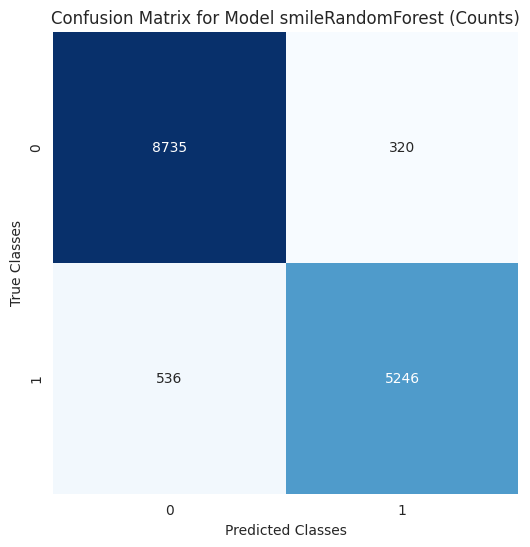

In [91]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns # Import seaborn for the new plot
from google.colab import files # Import files for downloading

# Make sure `best_model` and `results` are available from the previous kernel
if 'best_model' not in locals() or 'results' not in locals():
    print("Variables 'best_model' or 'results' not found. Please run the previous cells.")
else:
    # Get the results of the best model
    best_model_results = results[best_model]

    # Aggregate all y_val and y_proba from all folds
    all_y_true = np.concatenate(best_model_results['y_val_folds'])

    # Make sure y_proba_folds is not empty and contains valid arrays
    valid_y_proba_folds = [arr for arr in best_model_results['y_proba_folds'] if arr.size > 0]

    if valid_y_proba_folds:
        all_y_proba = np.concatenate(valid_y_proba_folds)
        # Convert probabilities into predicted classes (using 0.5 as the threshold)
        all_y_pred = (all_y_proba >= 0.5).astype(int)

        # Compute the confusion matrix
        cm = confusion_matrix(all_y_true, all_y_pred)

        # --- Plot 1: Confusion Matrix in Counts without internal lines ---
        fig1, ax1 = plt.subplots(figsize=(6, 6))
        # Use seaborn.heatmap for greater control over the lines
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                    xticklabels=[0, 1], yticklabels=[0, 1], ax=ax1, linewidths=0) # linewidths=0 removes the internal lines
        ax1.set_xlabel('Predicted Classes')
        ax1.set_ylabel('True Classes')
        ax1.set_title(f'Confusion Matrix for Model {best_model} (Counts)')

        # Save the plot with 300 DPI
        plot_filename_cm = f'confusion_matrix_{best_model}.png'
        plt.savefig(plot_filename_cm, dpi=300)
        print(f"Confusion Matrix plot saved as {plot_filename_cm}")
        files.download(plot_filename_cm)

        plt.show()

    else:
        print("There are no valid predicted probabilities for the best model.")

In [92]:
from google.colab import files

# Export the final DataFrame to a CSV file
train_val_full_combined_df.to_csv('train_val_combined_dataset.csv', index=False)
print("DataFrame successfully exported to 'train_val_combined_dataset.csv'")

# Download the file
files.download('train_val_combined_dataset.csv')

# Export the DataFrame with the test data to a CSV file
data_test_full.to_csv('test_dataset.csv', index=False)
print("Test DataFrame successfully exported to 'test_dataset.csv'")

# Download the file
files.download('test_dataset.csv')

DataFrame exportado com sucesso para 'train_val_combined_dataset.csv'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

DataFrame de teste exportado com sucesso para 'test_dataset.csv'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>